# Intraday Pairs Trading with Machine Learning Filters

## A Rolling Re-fit Benchmark on 1-minute S&P 500 Data

### ⚠️ Gatev-style variant (full-period walk-forward, no train/test split)

This version implements the **canonical Gatev et al. (2006) spread convention** 
for the distance and correlation methods:

- **Distance** and **correlation** (plus their K-means and AE filtered variants):
  normalized-price spread, `$1 long / $1 short`, no hedge ratio
- **Cointegration** methods: β-OLS hedge ratio (Engle-Granger / Vidyamurthy 2004)

This matches the original implementations in Gatev et al. (2006), Do & Faff 
(2010, 2012), and Sarmento & Horta (2020). The sibling notebook 
`pairs_trading_ml.ipynb` uses β-OLS for all 9 methods following Stübinger & 
Bredthauer (2017).

### Backtest design

We follow the methodological convention of Gatev et al. (2006) and Stübinger 
& Bredthauer (2017) by reporting performance on the **full walk-forward 
sequence**, without artificial train/test split. This is valid because our 
rolling ML refit design (K-means and autoencoder refit every 10 windows on 
strictly past data) ensures the entire period is effectively out-of-sample.

Temporal stability is assessed via **sub-period analysis** (4 contiguous 
segments) and **rolling Sharpe** (60-day window) in Section 6.


**Author:** Bryan Djoufack — M2 Research Project, 2026

Reproduces the high-frequency pairs trading framework of Stübinger & Bredthauer (2017) on S&P 500 
large caps, extended with machine learning filters (K-means, Autoencoder) to test whether modern 
pair selection can restore the profitability of classical strategies.

## Step 0 — Data preparation

Load M1 OHLC data, filter tickers by clean-day completeness, align to a common time grid. 
Output: `close_m1` (M1 close panel), `close_d` (daily close panel), `day_flags` (clean-day matrix).

In [2]:
# Bloc 0.2 — Imports and project constants

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# --- Path to CSV files (edit this to match your local folder) ---
DATA_DIR = Path(r"C:\Users\pc\Documents\M1 Data 2")   # <-- CHANGE THIS to your local folder

# --- CSV format ---
CSV_ENCODING = "utf-16-le"
CSV_SEPARATOR = "\t"
CSV_DATETIME_FORMAT = "%Y.%m.%d %H:%M:%S"

# --- Market session ---
# Data are in Europe/Paris time. Session observed: 16:35 to 22:54 Paris
# (= 9:35 to 15:54 ET). Provider trims the 5 open/close auction minutes.
BARS_PER_DAY = 380

# --- Cleaning thresholds (Step 0) ---
GAP_FLAG_MIN = 5       # gap >= 5 min  -> day flagged
GAP_EXCLUDE_MIN = 10   # gap >= 10 min -> day excluded from formation

print(f"DATA_DIR = {DATA_DIR}  (exists: {DATA_DIR.exists()})")


DATA_DIR = C:\Users\pc\Documents\M1 Data 2  (exists: True)


In [3]:
# Bloc 0.4 — Load all tickers

csv_files = sorted(DATA_DIR.glob("*_M1_data.csv"))
print(f"Found {len(csv_files)} CSV files in {DATA_DIR}")

data = {}
for i, path in enumerate(csv_files, 1):
    ticker = path.stem.split("_")[0]  # "AAPL_M1_data.csv" -> "AAPL"
    df = pd.read_csv(path, encoding=CSV_ENCODING, sep=CSV_SEPARATOR)
    df["Datetime"] = pd.to_datetime(df["Datetime"], format=CSV_DATETIME_FORMAT)
    df = df.set_index("Datetime").sort_index()
    df = df[~df.index.duplicated(keep="first")]  # drop exact duplicate timestamps
    data[ticker] = df
    if i % 10 == 0 or i == len(csv_files):
        print(f"  {i}/{len(csv_files)} loaded")

# Summary table: one row per ticker
summary = pd.DataFrame({
    "n_rows": {t: len(df) for t, df in data.items()},
    "start":  {t: df.index.min() for t, df in data.items()},
    "end":    {t: df.index.max() for t, df in data.items()},
})
summary.sort_index(inplace=True)
summary


Found 69 CSV files in C:\Users\pc\Documents\M1 Data 2
  10/69 loaded
  20/69 loaded
  30/69 loaded
  40/69 loaded
  50/69 loaded
  60/69 loaded
  69/69 loaded


,n_rows,start,end
AAPL,588647,2020-01-16 22:54:00,2026-03-30 22:54:00
ABBV,585042,2020-01-16 22:54:00,2026-03-30 22:54:00
ADBE,585753,2020-01-16 22:54:00,2026-03-30 22:54:00
AMD,588772,2020-01-16 22:54:00,2026-03-30 22:54:00
AMGN,586323,2020-01-16 22:54:00,2026-03-30 22:54:00
...,...,...,...
USB,587798,2020-01-16 22:54:00,2026-03-30 22:54:00
V,588379,2020-01-16 22:54:00,2026-03-30 22:54:00
VLO,587240,2020-01-16 22:54:00,2026-03-30 22:54:00
WFC,588595,2020-01-16 22:54:00,2026-03-30 22:54:00


In [4]:
# Bloc 0.5 — Remove duplicate tickers

close_raw = pd.concat({t: df["Close"] for t, df in data.items()}, axis=1).sort_index()

tickers = sorted(close_raw.columns)
duplicate_groups = []
already_seen = set()

for i, a in enumerate(tickers):
    if a in already_seen:
        continue
    group = {a}
    for b in tickers[i+1:]:
        if b in already_seen:
            continue
        pair = close_raw[[a, b]].dropna()
        if len(pair) == 0:
            continue
        max_diff = (pair[a] - pair[b]).abs().max()
        if max_diff < 1e-6:
            group.add(b)
    if len(group) > 1:
        duplicate_groups.append(group)
        already_seen.update(group)

if duplicate_groups:
    print(f"Found {len(duplicate_groups)} group(s) of tickers with identical prices:")
    for g in duplicate_groups:
        print(f"  {sorted(g)}")
    to_remove = set()
    for g in duplicate_groups:
        keep = sorted(g)[0]
        to_remove.update(g - {keep})
    print(f"\nRemoving {len(to_remove)} duplicated tickers: {sorted(to_remove)}")
    data = {t: df for t, df in data.items() if t not in to_remove}
    print(f"`data` now contains {len(data)} tickers.")
else:
    print("No duplicate tickers detected.")


No duplicate tickers detected.


In [5]:
# Bloc 0.6 — Day-level flagging

day_flags = {}

for ticker, df in data.items():
    # Group by day and compute: number of bars + max intraday gap (in minutes)
    g = df.groupby(df.index.date)
    n_bars = g.size()
    max_gap = g.apply(lambda d: d.index.to_series().diff().dt.total_seconds().max() / 60)

    flags = pd.DataFrame({
        "n_bars": n_bars,
        "max_gap_min": max_gap,
    })
    flags["incomplete_day"] = flags["n_bars"] < BARS_PER_DAY
    flags["has_gap_5min"]   = flags["max_gap_min"] >= GAP_FLAG_MIN
    flags["has_gap_10min"]  = flags["max_gap_min"] >= GAP_EXCLUDE_MIN

    day_flags[ticker] = flags

# Quick peek on one ticker
sample_ticker = list(day_flags.keys())[0]
print(f"day_flags['{sample_ticker}'] has {len(day_flags[sample_ticker])} days.")
day_flags[sample_ticker].head()


day_flags['AAPL'] has 1558 days.


,n_bars,max_gap_min,incomplete_day,has_gap_5min,has_gap_10min
2020-01-16,1,NaN,True,False,False
2020-01-17,374,4.0,True,False,False
2020-01-21,380,1.0,False,False,False
2020-01-22,380,1.0,False,False,False
2020-01-23,380,1.0,False,False,False


Tukey threshold (Q1 - 1.5*IQR) : 51.41%
Absolute threshold (85%)       : 85.00%
Effective threshold (stricter) : 85.00%
Tickers kept     : 39
Tickers excluded : 30  ['ABBV', 'ADBE', 'AMGN', 'AXP', 'BLK', 'BMY', 'CAT', 'CL', 'COST', 'CRM', 'EOG', 'FDX', 'GS', 'HD', 'HON', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'MPC', 'OXY', 'PFE', 'PNC', 'PSX', 'RTX', 'SCHW', 'TGT', 'UPS', 'VLO']


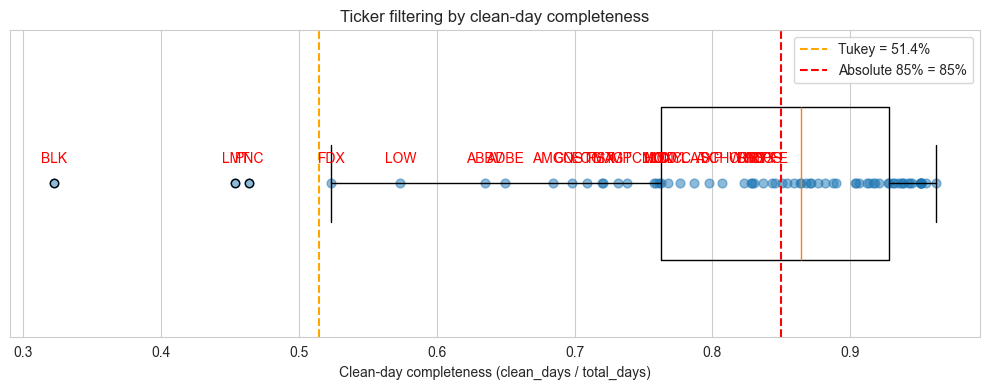


`data` and `day_flags` now contain 39 tickers.


In [6]:
# Bloc 0.7 — Filter tickers by clean-day completeness (Tukey + 85% floor)

clean_days = pd.Series({
    t: (~f["incomplete_day"] & ~f["has_gap_10min"]).sum()
    for t, f in day_flags.items()
})
total_days = pd.Series({t: len(f) for t, f in day_flags.items()})
completeness = clean_days / total_days

# Absolute threshold: at least 85% of days must be clean
abs_threshold = 0.85

# Tukey lower bound on the completeness ratio
q1, q3 = completeness.quantile(0.25), completeness.quantile(0.75)
iqr = q3 - q1
tukey_threshold = q1 - 1.5 * iqr

# A ticker must pass both rules => keep those above the stricter threshold
final_threshold = max(tukey_threshold, abs_threshold)
excluded = completeness[completeness < final_threshold].index.tolist()
kept = completeness[completeness >= final_threshold].index.tolist()

print(f"Tukey threshold (Q1 - 1.5*IQR) : {tukey_threshold:.2%}")
print(f"Absolute threshold (85%)       : {abs_threshold:.2%}")
print(f"Effective threshold (stricter) : {final_threshold:.2%}")
print(f"Tickers kept     : {len(kept)}")
print(f"Tickers excluded : {len(excluded)}  {excluded if excluded else ''}")

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(completeness, vert=False, widths=0.5)
ax.scatter(completeness, [1]*len(completeness), alpha=0.5, s=40)
for t in excluded:
    ax.annotate(t, (completeness[t], 1), textcoords="offset points", xytext=(0, 15),
                ha="center", color="red")
ax.axvline(tukey_threshold, color="orange", linestyle="--", label=f"Tukey = {tukey_threshold:.1%}")
ax.axvline(abs_threshold, color="red", linestyle="--", label=f"Absolute 85% = {abs_threshold:.0%}")
ax.set_xlabel("Clean-day completeness (clean_days / total_days)")
ax.set_yticks([])
ax.legend()
plt.title("Ticker filtering by clean-day completeness")
plt.tight_layout()
plt.show()

# Keep only valid tickers in both data and day_flags
data = {t: df for t, df in data.items() if t in kept}
day_flags = {t: f for t, f in day_flags.items() if t in kept}
print(f"\n`data` and `day_flags` now contain {len(data)} tickers.")


In [7]:
# Bloc 0.8 — Align tickers on common M1 time grid

close_m1 = pd.concat({t: df["Close"] for t, df in data.items()}, axis=1).sort_index()

print(f"Panel shape : {close_m1.shape}  (minutes x tickers)")
print(f"Date range  : {close_m1.index.min()} to {close_m1.index.max()}")
print(f"\nMissing values per ticker (top 5):")
print(close_m1.isna().sum().sort_values(ascending=False).head())

close_m1.head()


Panel shape : (588910, 39)  (minutes x tickers)
Date range  : 2020-01-16 22:54:00 to 2026-03-30 22:54:00

Missing values per ticker (top 5):
KO      1423
INTC    1155
USB     1112
BAC      722
MDLZ     709
dtype: int64


,AAPL,AMD,AMZN,AVGO,BA,BAC,C,COP,CSCO,CVS,...,QCOM,SBUX,SLB,TSLA,TXN,UNH,USB,V,WFC,XOM
Datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-16 22:54:00,315.06,49.66,93.847,30.700,331.90,34.72,80.97,65.04,48.98,75.91,...,91.70,92.56,38.77,171.11,130.05,299.61,55.11,201.29,49.20,68.91
2020-01-17 16:35:00,316.60,50.04,93.982,30.667,330.90,34.78,81.12,65.24,49.49,76.25,...,93.89,93.03,39.38,171.29,131.08,298.11,55.29,200.68,49.25,68.88
2020-01-17 16:36:00,315.85,49.90,93.676,30.677,330.71,34.80,81.14,65.26,49.46,76.39,...,93.55,93.06,39.43,170.96,131.02,298.45,55.39,200.29,49.29,68.86
2020-01-17 16:37:00,315.95,50.01,93.706,30.665,330.89,34.78,81.05,65.39,49.38,76.27,...,93.46,92.92,39.65,171.15,131.23,298.00,55.32,200.24,49.24,68.96
2020-01-17 16:38:00,315.82,49.97,93.551,30.622,330.82,34.75,80.98,65.38,49.34,76.21,...,93.26,92.80,39.72,171.45,131.18,298.60,55.33,200.03,49.16,69.00


In [8]:
# Bloc 0.10 — Reconstruct daily close from M1

close_daily = close_m1.resample("1D").last()

# Drop weekends / non-trading days (all NaN rows)
mask_any = close_daily.notna().any(axis=1)
close_daily = close_daily[mask_any]

print(f"Daily panel shape : {close_daily.shape}  (days x tickers)")
print(f"Date range        : {close_daily.index.min().date()} to {close_daily.index.max().date()}")
close_daily.head()


Daily panel shape : (1558, 39)  (days x tickers)
Date range        : 2020-01-16 to 2026-03-30


,AAPL,AMD,AMZN,AVGO,BA,BAC,C,COP,CSCO,CVS,...,QCOM,SBUX,SLB,TSLA,TXN,UNH,USB,V,WFC,XOM
Datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-16,315.06,49.66,93.847,30.700,331.90,34.72,80.97,65.04,48.98,75.91,...,91.70,92.56,38.77,171.11,130.05,299.61,55.11,201.29,49.20,68.91
2020-01-17,318.32,50.90,93.229,30.854,324.48,34.69,81.07,65.10,49.02,75.94,...,96.07,93.62,38.37,169.88,131.64,298.09,55.25,204.54,49.11,68.58
2020-01-21,316.30,51.01,94.504,30.762,312.94,34.24,79.92,64.03,48.73,74.40,...,94.42,92.34,36.98,182.53,130.59,300.13,54.38,206.41,48.90,67.64
2020-01-22,317.84,51.41,94.275,31.251,308.42,34.41,80.14,62.94,49.06,73.99,...,92.84,92.53,36.67,190.15,133.19,301.10,54.89,208.02,48.55,67.22
2020-01-23,319.45,51.68,94.189,31.914,317.26,34.14,79.82,63.15,48.97,73.55,...,91.90,93.75,36.42,190.66,134.28,299.59,54.91,206.78,48.22,66.74


In [9]:
# Bloc 0.11 — Data quality report

quality = pd.DataFrame({
    "total_days":   {t: len(f) for t, f in day_flags.items()},
    "clean_days":   {t: (~f["incomplete_day"] & ~f["has_gap_10min"]).sum() for t, f in day_flags.items()},
    "flagged_days": {t: f["has_gap_10min"].sum() for t, f in day_flags.items()},
})
quality["completeness_pct"] = 100 * quality["clean_days"] / quality["total_days"]
quality = quality.sort_values("completeness_pct", ascending=False)

print("=" * 60)
print("DATA QUALITY REPORT - Step 0 summary")
print("=" * 60)
print(f"Tickers retained      : {len(data)}")
print(f"Backtest period       : {close_m1.index.min().date()} to {close_m1.index.max().date()}")
print(f"Total trading days    : {len(close_daily)}")
print(f"Min clean days/ticker : {quality['clean_days'].min()}")
print(f"Max clean days/ticker : {quality['clean_days'].max()}")
print(f"Median completeness   : {quality['completeness_pct'].median():.2f}%")
print("=" * 60)

quality


DATA QUALITY REPORT - Step 0 summary
Tickers retained      : 39
Backtest period       : 2020-01-16 to 2026-03-30
Total trading days    : 1558
Min clean days/ticker : 1325
Max clean days/ticker : 1499
Median completeness   : 92.11%


,total_days,clean_days,flagged_days,completeness_pct
AMD,1558,1499,12,96.213094
AAPL,1558,1488,13,95.507060
AMZN,1558,1482,13,95.121951
NVDA,1558,1482,13,95.121951
TSLA,1558,1482,13,95.121951
MSFT,1558,1482,13,95.121951
CVX,1558,1482,13,95.121951
XOM,1558,1481,13,95.057766
JPM,1558,1472,13,94.480103
C,1558,1470,15,94.351733


## Step 0.12 — Warmup configuration (uniform across all methods)

To ensure a **fair like-for-like comparison between baseline and 
ML-filtered methods**, all backtests (classical and ML) skip the same 
warmup period. 

The ML methods (K-means and autoencoder, Steps 3–4) technically could 
start trading as soon as their first re-fit succeeds (windows 20–30 
depending on data availability). However, we uniformly skip 
`WARMUP_WINDOWS = ROLLING_HISTORY / 5` (~50 windows ≈ 252 trading days) 
for every method, so that all 9 methods trade exactly the same 
walk-forward windows.

This conservative choice trades off some training data (2020, partly 
COVID-impacted) against perfect comparability of results, which is 
essential for rigorous benchmark comparison.


In [10]:
# Bloc 0.12 — Warmup configuration

ROLLING_HISTORY = 252      # Days of past data used for rolling ML re-fit
ROLLING_DAYS_AE = 60       # AE lookback: rolling returns as input
REFIT_EVERY     = 10       # Re-fit K-means and AE every 10 windows (~2.5 months)

WARMUP_WINDOWS = ROLLING_HISTORY // 5   # ~50 windows skipped uniformly
print(f"ROLLING_HISTORY = {ROLLING_HISTORY} days (1 year)")
print(f"ROLLING_DAYS_AE = {ROLLING_DAYS_AE} days")
print(f"REFIT_EVERY     = {REFIT_EVERY} windows")
print(f"WARMUP_WINDOWS  = {WARMUP_WINDOWS}")
print(f"→ All 9 methods (baselines + K-means + AE) skip the first {WARMUP_WINDOWS} windows")
print(f"→ First trade: window {WARMUP_WINDOWS}, approximately day {WARMUP_WINDOWS*5}")
print(f"→ All methods thus trade on the EXACT same train+test windows")


ROLLING_HISTORY = 252 days (1 year)
ROLLING_DAYS_AE = 60 days
REFIT_EVERY     = 10 windows
WARMUP_WINDOWS  = 50
→ All 9 methods (baselines + K-means + AE) skip the first 50 windows
→ First trade: window 50, approximately day 250
→ All methods thus trade on the EXACT same train+test windows


## Step 1 — Intraday pairs trading baseline (no ML)

This step implements the classical pairs trading pipeline (no ML filter). It 
serves as the **baseline** against which K-means and Autoencoder filters will be 
compared in Steps 3 and 4.

### Scope for this step

To keep the pipeline focused and tractable, we restrict Step 1 to :

- **2 selection criteria** : **distance** (Gatev et al. 2006) and 
  **cointegration** (Engle-Granger, Vidyamurthy 2004 ; Caldeira & Moura 2013)
- **1 trading rule** : **varying Bollinger bands** (Kishore 2012 ; Stübinger & 
  Bredthauer 2017), identified as best-performing in high-frequency settings
- **1 threshold parameter** : **k = 2.5** (Stübinger & Bredthauer 2017 report 
  k=2.5 as optimal on 1-minute data, while k=2 is too aggressive at HF)
- **Top 10 pairs** per criterion per window (concentrated portfolio)
- **Position sizing** : dollar-neutral with hedge ratio β, normalized to a unit 
  gross exposure per pair (long `1/(1+β)` in A, short `β/(1+β)` in B)

### Walk-forward design (Specification A — main)

- **Formation window** : 10 trading days at M1 frequency (~3 800 observations), 
  following Stübinger & Bredthauer (2017)
- **Trading window** : 5 trading days at M1 frequency (non-overlapping)
- **Roll** : step = 5 days, no overlap between trading windows

### PnL convention for Step 1

PnL is computed **mid-price without transaction costs** at this stage. Realistic 
execution (spread, commission, slippage) is added in Step 2.

### Formation-window integrity

Days flagged with `has_gap_10min = True` are excluded pair-by-pair when computing 
distances, correlations or cointegration tests — β and test statistics would 
otherwise be estimated on partial data.


In [11]:
# Bloc 1.0 — Data range (single full-period backtest)

data_start = close_m1.index.min().normalize()
data_end   = close_m1.index.max().normalize()
n_days = len(close_daily.index)

print(f"Data range         : {data_start.date()} to {data_end.date()}")
print(f"Total trading days : {n_days}")
print(f"Backtest design    : single full-period walk-forward (no train/test split)")
print(f"Warmup applied     : {ROLLING_HISTORY} days ({WARMUP_WINDOWS} windows skipped)")
print(f"Effective trading  : {n_days - ROLLING_HISTORY} days, ~{WARMUP_WINDOWS} fewer windows than total")


Data range         : 2020-01-16 to 2026-03-30
Total trading days : 1558
Backtest design    : single full-period walk-forward (no train/test split)
Warmup applied     : 252 days (50 windows skipped)
Effective trading  : 1306 days, ~50 fewer windows than total


In [12]:
# Bloc 1.1 — Walk-forward windows (single sequence)

FORMATION_DAYS = 10
TRADING_DAYS   = 5
STEP           = 5  # no overlap

trading_dates = close_daily.index

windows = []
for start in range(0, len(trading_dates) - (FORMATION_DAYS + TRADING_DAYS - 1), STEP):
    formation = trading_dates[start : start + FORMATION_DAYS]
    trading   = trading_dates[start + FORMATION_DAYS : start + FORMATION_DAYS + TRADING_DAYS]
    if len(trading) == TRADING_DAYS:
        windows.append((formation, trading))

# Warmup-aware: effective windows = all windows minus WARMUP_WINDOWS
# But we still expose the full list `windows` for the rolling refit loops.
# The WARMUP_WINDOWS skip is applied inside each backtest function.
windows_all = windows  # alias for clarity

print(f"Total walk-forward windows : {len(windows)}")
print(f"Warmup windows (skipped)   : {WARMUP_WINDOWS}")
print(f"Effective traded windows   : {len(windows) - WARMUP_WINDOWS}")
print(f"First traded window start  : {windows[WARMUP_WINDOWS][0][0].date()}")
print(f"Last traded window end     : {windows[-1][1][-1].date()}")




Total walk-forward windows : 309
Warmup windows (skipped)   : 50
Effective traded windows   : 259
First traded window start  : 2021-01-13
Last traded window end     : 2026-03-25


In [13]:
# Bloc 1.2 — Pair selection: distance method (Gatev 2006)

from scipy.spatial.distance import pdist, squareform

def select_pairs_distance(formation_days, close_m1, day_flags, top_n=5):
    """Select top N pairs by smallest Euclidean distance on Gatev-normalized prices."""
    # Extract prices on the formation window
    start = formation_days[0]
    end   = formation_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end].dropna(axis=1, how="all")
    tickers = prices.columns.tolist()
    
    # Global exclusion: drop days where any ticker has a >= 10 min gap
    flagged_dates = set()
    for t in tickers:
        flagged_dates.update(day_flags[t].index[day_flags[t]["has_gap_10min"]])
    keep = ~prices.index.normalize().isin([pd.Timestamp(d) for d in flagged_dates])
    prices = prices[keep].dropna(axis=0, how="any")
    
    # Gatev normalization: each series starts at 1
    norm = prices / prices.iloc[0]
    
    # Vectorized pairwise Euclidean distance
    dist_vec = pdist(norm.values.T, metric="euclidean")
    dist_mat = squareform(dist_vec)
    
    # Top N pairs (i < j, smallest distance)
    n = len(tickers)
    i_idx, j_idx = np.triu_indices(n, k=1)
    pair_dists = dist_mat[i_idx, j_idx]
    order = np.argsort(pair_dists)[:top_n]
    
    return [(tickers[i_idx[k]], tickers[j_idx[k]], pair_dists[k]) for k in order]


# Test on the first window
pairs = select_pairs_distance(windows[0][0], close_m1, day_flags, top_n=5)
print(f"Top 5 pairs by distance on first window ({windows[0][0][0].date()} to {windows[0][0][-1].date()}):")
for a, b, d in pairs:
    print(f"  {a:6} - {b:6}  distance = {d:.4f}")


Top 5 pairs by distance on first window (2020-01-16 to 2020-01-30):
  COP    - XOM     distance = 0.2334
  BAC    - C       distance = 0.2541
  JPM    - USB     distance = 0.2561
  C      - MS      distance = 0.2966
  CSCO   - NKE     distance = 0.3738


In [14]:
# Bloc 1.3 — Pair selection: cointegration (Engle-Granger, p < 0.05)

from itertools import combinations
from statsmodels.tsa.stattools import adfuller

def select_pairs_cointegration(formation_days, close_m1, day_flags, top_n=5, pvalue_max=0.05):
    """Select top N pairs with ADF p-value < pvalue_max on OLS residuals."""
    start = formation_days[0]
    end   = formation_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end].dropna(axis=1, how="all")
    tickers = prices.columns.tolist()
    
    # Exclude flagged days (gap >= 10 min for any ticker)
    flagged_dates = set()
    for t in tickers:
        flagged_dates.update(day_flags[t].index[day_flags[t]["has_gap_10min"]])
    keep = ~prices.index.normalize().isin([pd.Timestamp(d) for d in flagged_dates])
    prices = prices[keep].dropna(axis=0, how="any")
    
    # Engle-Granger on each pair: OLS then ADF on residuals
    results = []
    for a, b in combinations(tickers, 2):
        pa = prices[a].values
        pb = prices[b].values
        beta, alpha = np.polyfit(pb, pa, deg=1)
        residuals = pa - (alpha + beta * pb)
        try:
            pvalue = adfuller(residuals, maxlag=1, regression="c", autolag=None)[1]
        except Exception:
            continue
        results.append((a, b, pvalue))
    
    # Keep only significant pairs (p < pvalue_max), then take top N
    significant = [r for r in results if r[2] < pvalue_max]
    significant.sort(key=lambda x: x[2])
    return significant[:top_n]


# Test on the first window
pairs = select_pairs_cointegration(windows[0][0], close_m1, day_flags, top_n=5, pvalue_max=0.05)
print(f"Cointegrated pairs (p<0.05) on first window ({windows[0][0][0].date()} to {windows[0][0][-1].date()}):")
print(f"  {len(pairs)} significant pair(s) found")
for a, b, p in pairs:
    print(f"  {a:6} - {b:6}  ADF p-value = {p:.4f}")


Cointegrated pairs (p<0.05) on first window (2020-01-16 to 2020-01-30):
  5 significant pair(s) found
  AMZN   - V       ADF p-value = 0.0001
  CVX    - QCOM    ADF p-value = 0.0002
  CVX    - MS      ADF p-value = 0.0004
  CSCO   - UNH     ADF p-value = 0.0013
  NKE    - UNH     ADF p-value = 0.0021


In [15]:
# Bloc 1.3.5 — Pair selection: Pearson correlation

def select_pairs_correlation(formation_days, close_m1, day_flags,
                              top_n=10, corr_min=0.70):
    """Select top N pairs by Pearson correlation of M1 returns (>= corr_min)."""
    start = formation_days[0]
    end   = formation_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end].dropna(axis=1, how="all")
    tickers = prices.columns.tolist()
    
    flagged = set()
    for t in tickers:
        flagged.update(day_flags[t].index[day_flags[t]["has_gap_10min"]])
    keep = ~prices.index.normalize().isin([pd.Timestamp(d) for d in flagged])
    prices = prices[keep].dropna(axis=0, how="any")
    
    returns = prices.pct_change().dropna()
    corr_mat = returns.corr().values
    
    from itertools import combinations
    results = []
    for i, j in combinations(range(len(tickers)), 2):
        c = corr_mat[i, j]
        if np.isnan(c):
            continue
        if c >= corr_min:
            results.append((tickers[i], tickers[j], c))
    
    # Highest correlation first
    results.sort(key=lambda x: x[2], reverse=True)
    return results[:top_n]


# Test on first window
pairs_corr = select_pairs_correlation(windows[0][0], close_m1, day_flags,
                                       top_n=10, corr_min=0.70)
print(f"Correlation pairs (corr>=0.70) on first window: {len(pairs_corr)} selected")
for a, b, c in pairs_corr:
    print(f"  {a:6} - {b:6}  corr = {c:.4f}")


Correlation pairs (corr>=0.70) on first window: 10 selected
  BAC    - C       corr = 0.8721
  BAC    - JPM     corr = 0.8662
  C      - JPM     corr = 0.8531
  CVX    - XOM     corr = 0.8355
  C      - MS      corr = 0.8145
  BAC    - MS      corr = 0.8093
  COP    - SLB     corr = 0.8038
  COP    - CVX     corr = 0.7937
  COP    - XOM     corr = 0.7873
  BAC    - USB     corr = 0.7711


In [16]:
# Bloc 1.4 — Hedge ratio and spread construction

def compute_hedge_ratio(formation_days, ticker_a, ticker_b, close_m1, day_flags):
    """Estimate beta by OLS on formation window prices."""
    start = formation_days[0]
    end   = formation_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end, [ticker_a, ticker_b]]
    
    # Exclude days flagged for either ticker
    flagged = set()
    flagged.update(day_flags[ticker_a].index[day_flags[ticker_a]["has_gap_10min"]])
    flagged.update(day_flags[ticker_b].index[day_flags[ticker_b]["has_gap_10min"]])
    keep = ~prices.index.normalize().isin([pd.Timestamp(d) for d in flagged])
    prices = prices[keep].dropna()
    
    pa = prices[ticker_a].values
    pb = prices[ticker_b].values
    beta, alpha = np.polyfit(pb, pa, deg=1)
    return alpha, beta

def build_spread(trading_days, ticker_a, ticker_b, beta, close_m1):
    """Build spread s_t = P_A_t - beta * P_B_t over the trading window."""
    start = trading_days[0]
    end   = trading_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end, [ticker_a, ticker_b]].dropna()
    spread = prices[ticker_a] - beta * prices[ticker_b]
    return spread

# Test: use the first pair from the cointegration selection (Bloc 1.3)
a, b, _ = pairs[0]
alpha, beta = compute_hedge_ratio(windows[0][0], a, b, close_m1, day_flags)
spread = build_spread(windows[0][1], a, b, beta, close_m1)

print(f"Pair: {a} - {b}")
print(f"alpha = {alpha:.4f}, beta = {beta:.4f}")
print(f"\nSpread on trading window ({windows[0][1][0].date()} to {windows[0][1][-1].date()}):")
print(f"  Length: {len(spread)} observations")
print(f"  Mean:   {spread.mean():.4f}")
print(f"  Std:    {spread.std():.4f}")


Pair: AMZN - V
alpha = 23.8302, beta = 0.3382

Spread on trading window (2020-01-31 to 2020-02-06):
  Length: 1897 observations
  Mean:   33.5014
  Std:    0.5753


In [17]:
# Bloc 1.4bis — Note on hedge ratio convention

print("Bloc 1.4bis: documentation only — no alternative functions defined.")
print("All methods use compute_pair_pnl / compute_pair_pnl_net from Blocs 1.6/2.2.")


Bloc 1.4bis: documentation only — no alternative functions defined.
All methods use compute_pair_pnl / compute_pair_pnl_net from Blocs 1.6/2.2.


In [18]:
# Bloc 1.5 — Trading rule: varying Bollinger bands (k=2.5)

def _run_state_machine(z_array, k):
    """State machine for pair trading positions (+1 long spread, -1 short, 0 flat)."""
    n = len(z_array)
    pos = np.zeros(n, dtype=np.int8)
    state = 0
    for i in range(n):
        zi = z_array[i]
        if np.isnan(zi):
            pos[i] = state  # keep last known state when z is NaN
            continue
        if state == 0:
            if zi < -k:
                state = 1
            elif zi > k:
                state = -1
        elif state == 1:   # long spread -> exit when z crosses back up through 0
            if zi >= 0:
                state = 0
        elif state == -1:  # short spread -> exit when z crosses back down through 0
            if zi <= 0:
                state = 0
        pos[i] = state
    return pos


def generate_signals(formation_days, trading_days, ticker_a, ticker_b, beta,
                     close_m1, k=2.5, rolling_window=380):
    """
    Return (spread, z, position) Series indexed on the trading window.
    Uses the last day of formation as warm-up for the rolling statistics.
    """
    warmup_start = formation_days[-1]
    trading_end  = trading_days[-1] + pd.Timedelta(days=1)
    
    prices = close_m1.loc[warmup_start:trading_end, [ticker_a, ticker_b]].dropna()
    spread_vals = prices[ticker_a].values - beta * prices[ticker_b].values
    
    s = pd.Series(spread_vals)
    mu = s.rolling(rolling_window, min_periods=rolling_window).mean().values
    sd = s.rolling(rolling_window, min_periods=rolling_window).std().values
    z_vals = (spread_vals - mu) / sd
    
    pos_vals = _run_state_machine(z_vals, k)
    
    idx = prices.index
    spread = pd.Series(spread_vals, index=idx)
    z      = pd.Series(z_vals, index=idx)
    pos    = pd.Series(pos_vals, index=idx)
    
    # Restrict to trading window (drop warm-up period)
    trading_start = trading_days[0]
    spread = spread.loc[trading_start:]
    z      = z.loc[trading_start:]
    pos    = pos.loc[trading_start:]
    
    # Force close at the last bar of the trading window
    if len(pos) > 0:
        pos.iloc[-1] = 0
    
    return spread, z, pos


# Test with the first pair from cointegration selection (Bloc 1.3)
a, b, _ = pairs[0]
alpha, beta = compute_hedge_ratio(windows[0][0], a, b, close_m1, day_flags)
spread, z, position = generate_signals(
    windows[0][0], windows[0][1], a, b, beta, close_m1, k=2.5
)

print(f"Pair: {a} - {b}, beta = {beta:.4f}")
print(f"Trading bars : {len(position)}")
print(f"Z-score range: [{z.min():.2f}, {z.max():.2f}]")
print(f"Position counts:\n{position.value_counts().sort_index()}")
print(f"Number of position changes: {(position.diff().fillna(0) != 0).sum()}")


Pair: AMZN - V, beta = 0.3382
Trading bars : 1897
Z-score range: [-6.05, 17.33]
Position counts:
-1    713
 0    869
 1    315
Name: count, dtype: int64
Number of position changes: 7


In [19]:
# Bloc 1.6 — Per-pair PnL (Gatev 2006 eq 2-3, method-specific)

def compute_pair_pnl(position, ticker_a, ticker_b, close_m1, trading_days, beta=None):
    """Per-bar pair return, Gatev eq (2)-(3) compounded weights.
    
    Args:
        position: Series of +1/-1/0 on trading bars (from generate_signals)
        ticker_a, ticker_b: pair tickers
        close_m1: price panel
        trading_days: list of trading window days
        beta: If None (distance/correlation) → $1 long / $1 short (w_A = w_B = 0.5).
              If provided (cointegration) → w_A = 1/(1+|β|), w_B = |β|/(1+|β|).
    
    Returns:
        Series of bar-level pair returns in fractional units (e.g. 0.001 = 10 bps).
    """
    start = trading_days[0]
    end   = trading_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end, [ticker_a, ticker_b]].dropna()
    if len(prices) < 2:
        return pd.Series(dtype=float)
    
    pos = position.reindex(prices.index).ffill().fillna(0).values.astype(np.int8)
    r_a = prices[ticker_a].pct_change().fillna(0.0).values
    r_b = prices[ticker_b].pct_change().fillna(0.0).values
    
    # Initial weights depend on method
    if beta is None:
        w_a_init = 0.5
        w_b_init = 0.5
    else:
        abs_beta = abs(beta)
        w_a_init = 1.0 / (1.0 + abs_beta)
        w_b_init = abs_beta / (1.0 + abs_beta)
    
    n = len(prices)
    pair_ret = np.zeros(n)
    w_a = w_a_init
    w_b = w_b_init
    prev_pos = 0
    
    for t in range(1, n):
        pos_prev = pos[t-1]
        # Reset weights on new trade open (flat → position)
        if prev_pos == 0 and pos_prev != 0:
            w_a = w_a_init
            w_b = w_b_init
        if pos_prev != 0:
            pair_ret[t] = pos_prev * (w_a * r_a[t] - w_b * r_b[t])
            # Compound weights (buy-and-hold)
            w_a = w_a * (1.0 + r_a[t])
            w_b = w_b * (1.0 + r_b[t])
        else:
            w_a = w_a_init
            w_b = w_b_init
        prev_pos = pos_prev
    
    return pd.Series(pair_ret, index=prices.index)


# Test — show both conventions for the same pair
a, b, _ = pairs[0]
alpha, beta = compute_hedge_ratio(windows[0][0], a, b, close_m1, day_flags)
spread, z, position = generate_signals(
    windows[0][0], windows[0][1], a, b, beta, close_m1, k=2.5
)

pnl_coint = compute_pair_pnl(position, a, b, close_m1, windows[0][1], beta=beta)
pnl_dist  = compute_pair_pnl(position, a, b, close_m1, windows[0][1], beta=None)

print(f"Pair: {a} - {b},  β = {beta:.4f}")
print()
print("COINTEGRATION convention (β-weighted):")
print(f"  Total return    : {pnl_coint.sum():+.6f}  ({pnl_coint.sum()*100:+.4f}%)")
print(f"  Std return/bar  : {pnl_coint.std():.6f}")
print()
print("DISTANCE/CORRELATION convention ($1/$1):")
print(f"  Total return    : {pnl_dist.sum():+.6f}  ({pnl_dist.sum()*100:+.4f}%)")
print(f"  Std return/bar  : {pnl_dist.std():.6f}")
print()
print(f"Position changes  : {(position.diff().fillna(0) != 0).sum()}")


Pair: AMZN - V,  β = 0.3382

COINTEGRATION convention (β-weighted):
  Total return    : +0.009761  (+0.9761%)
  Std return/bar  : 0.000402

DISTANCE/CORRELATION convention ($1/$1):
  Total return    : -0.004397  (-0.4397%)
  Std return/bar  : 0.000307

Position changes  : 7


In [20]:
# Bloc 1.7 — Backtest loop: 3 baseline methods (full period)

import time

TOP_N = 10
K_THRESHOLD = 2.5
PVALUE_MAX = 0.05
CORR_MIN = 0.70


def run_backtest_baseline(windows_subset, label, skip_first=0):
    """Run the 3-baseline-method backtest."""
    pnl_d_list, pnl_c_list, pnl_r_list = [], [], []
    pairs_log_rows = []
    t0 = time.time()
    
    windows_effective = windows_subset[skip_first:] if skip_first > 0 else windows_subset
    n_total = len(windows_effective)
    for i, (formation_days, trading_days) in enumerate(windows_effective):
        if i % 20 == 0:
            print(f"  [{label}] Window {i}/{n_total}  ({time.time()-t0:.0f}s)")
        
        trading_start = trading_days[0]
        trading_end   = trading_days[-1] + pd.Timedelta(days=1)
        window_index  = close_m1.loc[trading_start:trading_end].index
        
        pairs_dist  = select_pairs_distance(formation_days, close_m1, day_flags, top_n=TOP_N)
        pairs_coint = select_pairs_cointegration(formation_days, close_m1, day_flags,
                                                  top_n=TOP_N, pvalue_max=PVALUE_MAX)
        pairs_corr  = select_pairs_correlation(formation_days, close_m1, day_flags,
                                                top_n=TOP_N, corr_min=CORR_MIN)
        
        for method_name, pair_list, bucket in [
            ("distance",      pairs_dist,  pnl_d_list),
            ("cointegration", pairs_coint, pnl_c_list),
            ("correlation",   pairs_corr,  pnl_r_list),
        ]:
            pair_pnls = []
            for (a, b, score) in pair_list:
                alpha, beta = compute_hedge_ratio(formation_days, a, b, close_m1, day_flags)
                spread, z, position = generate_signals(
                    formation_days, trading_days, a, b, beta, close_m1, k=K_THRESHOLD
                )
                pnl_beta = beta if "cointegration" in method_name else None
                pnl = compute_pair_pnl(position, a, b, close_m1, trading_days, beta=pnl_beta)
                pair_pnls.append(pnl)
                pairs_log_rows.append({
                    "period":        label,
                    "window_idx":    i,
                    "trading_start": trading_days[0],
                    "method":        method_name,
                    "ticker_a": a, "ticker_b": b,
                    "score": score, "beta": beta,
                    "pair_total_pnl": pnl.sum(),
                })
            if pair_pnls:
                bucket.append(pd.concat(pair_pnls, axis=1).mean(axis=1))
            else:
                bucket.append(pd.Series(0.0, index=window_index))
    
    print(f"  [{label}] Done in {time.time()-t0:.0f}s")
    return (pd.concat(pnl_d_list), pd.concat(pnl_c_list), pd.concat(pnl_r_list),
            pd.DataFrame(pairs_log_rows))


# Single full-period backtest, warmup applied uniformly
print("=== FULL PERIOD BACKTEST ===")
(pnl_distance, pnl_coint, pnl_corr,
 pairs_log) = run_backtest_baseline(windows_all, "full", skip_first=WARMUP_WINDOWS)

print("\nSummary:")
for name, pnl in [
    ("distance",      pnl_distance),
    ("cointegration", pnl_coint),
    ("correlation",   pnl_corr),
]:
    print(f"  {name:14} full-period PnL = {pnl.sum():+.3f}")


=== FULL PERIOD BACKTEST ===
  [full] Window 0/259  (0s)
  [full] Window 20/259  (63s)
  [full] Window 40/259  (121s)
  [full] Window 60/259  (181s)
  [full] Window 80/259  (241s)
  [full] Window 100/259  (320s)
  [full] Window 120/259  (365s)
  [full] Window 140/259  (420s)
  [full] Window 160/259  (475s)
  [full] Window 180/259  (528s)
  [full] Window 200/259  (587s)
  [full] Window 220/259  (629s)
  [full] Window 240/259  (667s)
  [full] Done in 706s

Summary:
  distance       full-period PnL = +0.197
  cointegration  full-period PnL = +0.074
  correlation    full-period PnL = +0.345


In [21]:
# Bloc 1.8 — Performance metrics (full period)

def compute_metrics(pnl_m1, pairs_log=None, method_name=""):
    """Compute summary performance metrics from an M1 PnL series."""
    daily_pnl = pnl_m1.groupby(pnl_m1.index.date).sum()
    
    total_pnl = pnl_m1.sum()
    n_days    = len(daily_pnl)
    mean_day  = daily_pnl.mean()
    std_day   = daily_pnl.std()
    sharpe    = mean_day / std_day * np.sqrt(252) if std_day > 0 else np.nan
    
    neg = daily_pnl[daily_pnl < 0]
    sortino = mean_day / neg.std() * np.sqrt(252) if len(neg) > 1 else np.nan
    
    cum = daily_pnl.cumsum()
    dd  = cum - cum.cummax()
    max_dd = dd.min()
    
    n_pair_selections = None
    n_trades = None
    if pairs_log is not None and method_name:
        sub = pairs_log[pairs_log["method"] == method_name]
        n_pair_selections = len(sub)
        if "pair_gross_pnl" in sub.columns and "pair_net_pnl" in sub.columns:
            # Method 1 (with costs): count from cost structure
            total_cost = (sub["pair_gross_pnl"] - sub["pair_net_pnl"]).sum()
            n_halfturns = total_cost / 3e-4
            n_trades = int(n_halfturns / 2)
        elif "pair_total_pnl" in sub.columns:
            # Method 2 (no costs): count distinct windows × pairs as proxy for trades
            # Each pair in a trading window is one trade opportunity
            n_trades = len(sub)
    
    return {
        "method":            method_name,
        "total_pnl":         total_pnl,
        "n_days":            n_days,
        "mean_daily":        mean_day,
        "std_daily":         std_day,
        "sharpe":            sharpe,
        "sortino":           sortino,
        "max_drawdown":      max_dd,
        "n_pair_selections": n_pair_selections,
        "n_trades":          n_trades,
    }


# Full-period metrics (single sequence, no train/test split)
rows = []
for method_name, pnl_m in [("distance", pnl_distance), 
                             ("cointegration", pnl_coint), 
                             ("correlation", pnl_corr)]:
    m = compute_metrics(pnl_m, pairs_log, method_name)
    m["method"] = method_name
    rows.append(m)

metrics_baseline = (pd.DataFrame(rows)
                    .set_index("method")
                    [["total_pnl", "sharpe", "sortino", "max_drawdown",
                      "n_pair_selections", "n_trades"]])
print("Baseline performance metrics (mid-price, no costs, full period):")
metrics_baseline


Baseline performance metrics (mid-price, no costs, full period):


,total_pnl,sharpe,sortino,max_drawdown,n_pair_selections,n_trades
method,,,,,,
distance,0.196529,1.145284,1.421567,-0.042007,2590,2590
cointegration,0.074058,0.189477,0.231198,-0.163740,2590,2590
correlation,0.344900,1.762785,2.130631,-0.032920,1971,1971


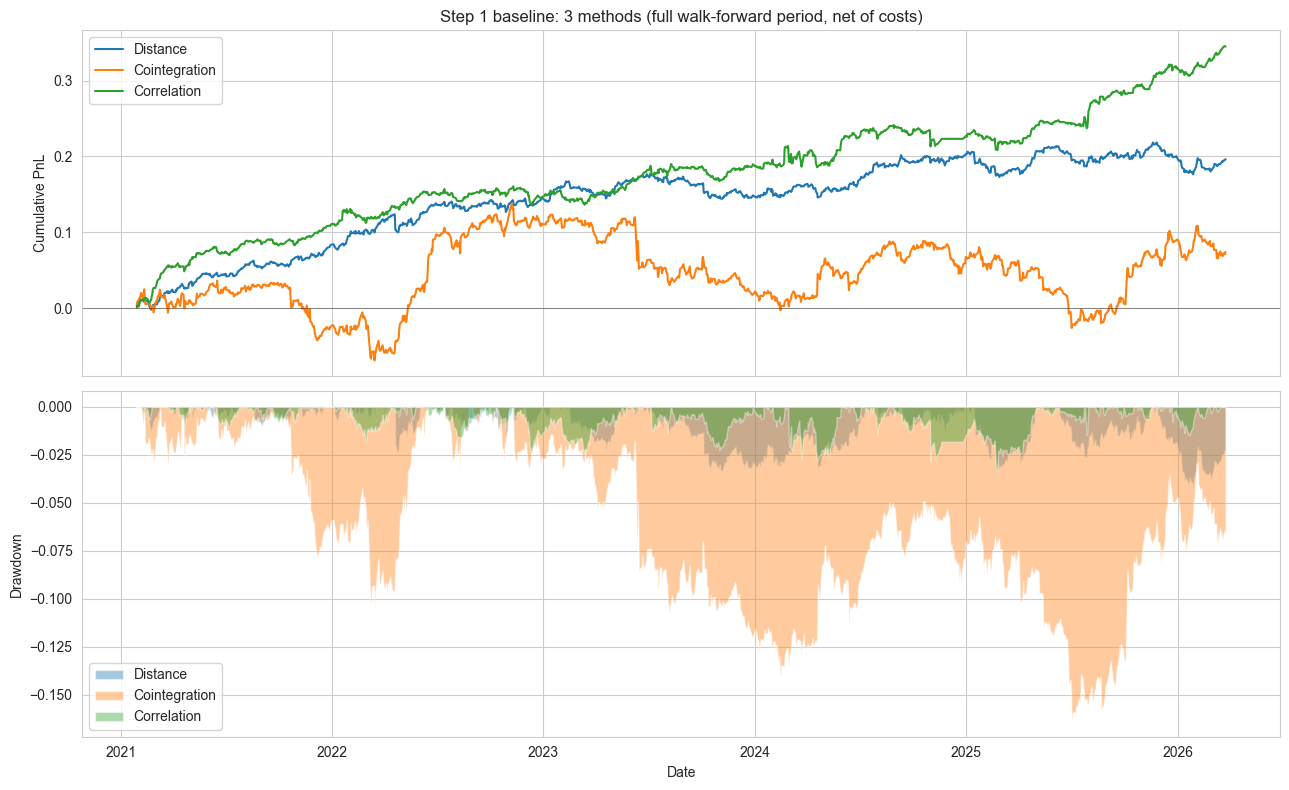

In [22]:
# Bloc 1.9 — Equity curves (full period)

daily_dist  = pnl_distance.groupby(pnl_distance.index.date).sum()
daily_coint = pnl_coint.groupby(pnl_coint.index.date).sum()
daily_corr  = pnl_corr.groupby(pnl_corr.index.date).sum()
daily_dist.index  = pd.to_datetime(daily_dist.index)
daily_coint.index = pd.to_datetime(daily_coint.index)
daily_corr.index  = pd.to_datetime(daily_corr.index)

cum_dist  = daily_dist.cumsum()
cum_coint = daily_coint.cumsum()
cum_corr  = daily_corr.cumsum()
dd_dist  = cum_dist  - cum_dist.cummax()
dd_coint = cum_coint - cum_coint.cummax()
dd_corr  = cum_corr  - cum_corr.cummax()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(cum_dist.index,  cum_dist.values,  label="Distance",      lw=1.5)
axes[0].plot(cum_coint.index, cum_coint.values, label="Cointegration", lw=1.5)
axes[0].plot(cum_corr.index,  cum_corr.values,  label="Correlation",   lw=1.5)
axes[0].axhline(0, color="k", lw=0.5, alpha=0.5)
axes[0].set_ylabel("Cumulative PnL")
axes[0].set_title("Step 1 baseline: 3 methods (full walk-forward period, net of costs)")
axes[0].legend()

axes[1].fill_between(dd_dist.index,  dd_dist.values,  0, alpha=0.4, label="Distance")
axes[1].fill_between(dd_coint.index, dd_coint.values, 0, alpha=0.4, label="Cointegration")
axes[1].fill_between(dd_corr.index,  dd_corr.values,  0, alpha=0.4, label="Correlation")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()



=== Top 10 BEST pairs by distance ===
  method ticker_a ticker_b  total_pnl  n_windows  mean_pnl
distance     GOOG     MSFT   0.161480         19  0.008499
distance     CSCO        V   0.156636         19  0.008244
distance     MDLZ      PEP   0.150054         50  0.003001
distance      BAC      USB   0.149829         41  0.003654
distance       KO      PEP   0.145856         86  0.001696
distance       KO       PG   0.144986         63  0.002301
distance       KO     MDLZ   0.137565         56  0.002457
distance      BAC      JPM   0.130955         59  0.002220
distance      USB      WFC   0.119134         24  0.004964
distance     MDLZ       PG   0.116063         43  0.002699

=== Top 10 WORST pairs by distance ===
  method ticker_a ticker_b  total_pnl  n_windows  mean_pnl
distance     AMZN     NFLX  -0.170608          2 -0.085304
distance     INTC       MS  -0.105989          2 -0.052995
distance       MS      WFC  -0.087716         20 -0.004386
distance      PEP     SBUX  -0.08194

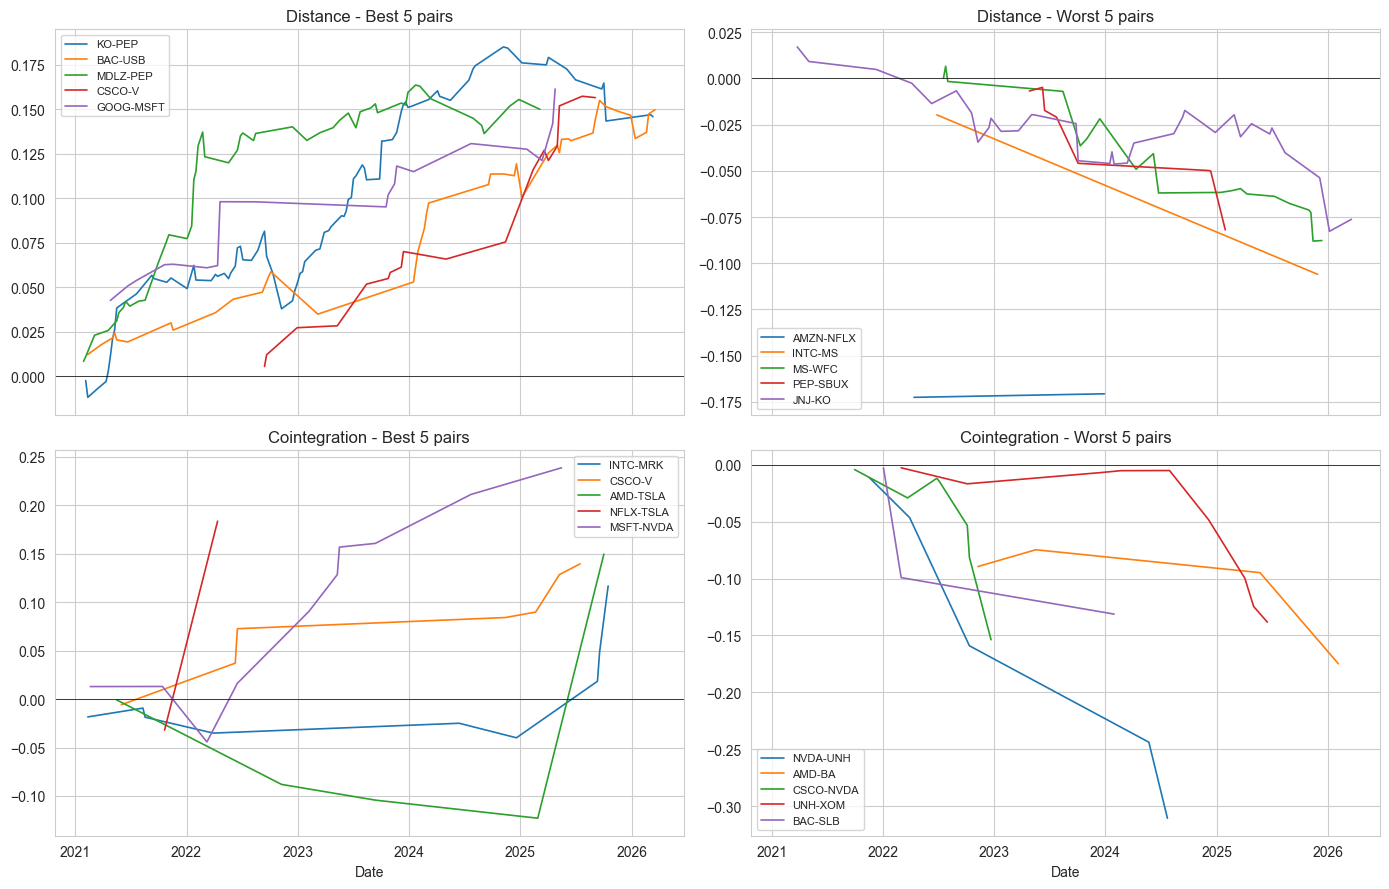

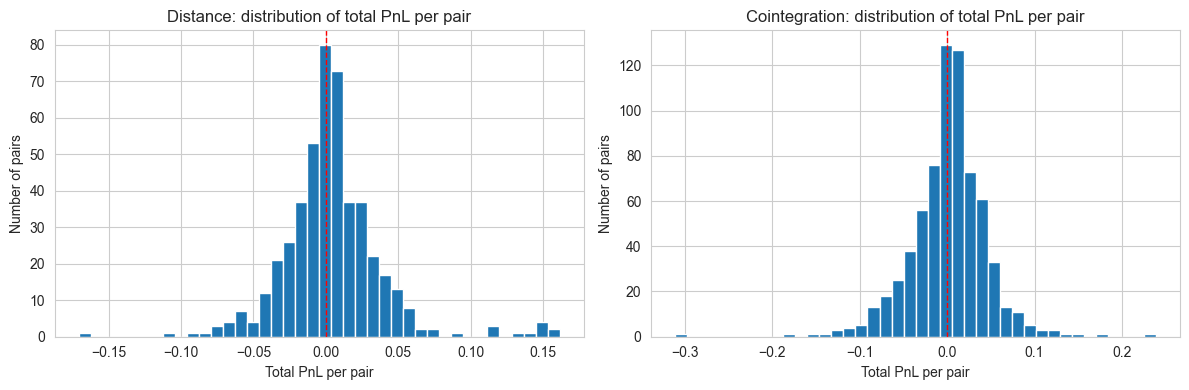

In [23]:
# Bloc 1.10 — Per-pair PnL diagnostic

pair_summary = (
    pairs_log.groupby(["method", "ticker_a", "ticker_b"])
    .agg(total_pnl=("pair_total_pnl", "sum"),
         n_windows=("pair_total_pnl", "size"),
         mean_pnl=("pair_total_pnl", "mean"))
    .reset_index()
)

# Show best and worst pairs per method
for method in ["distance", "cointegration"]:
    sub = pair_summary[pair_summary["method"] == method].sort_values("total_pnl", ascending=False)
    print(f"\n=== Top 10 BEST pairs by {method} ===")
    print(sub.head(10).to_string(index=False))
    print(f"\n=== Top 10 WORST pairs by {method} ===")
    print(sub.tail(10).iloc[::-1].to_string(index=False))

# Equity curves: for each method, the 5 best and 5 worst pairs
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for row, method in enumerate(["distance", "cointegration"]):
    sub = pairs_log[pairs_log["method"] == method].copy()
    sub["pair"] = sub["ticker_a"] + "-" + sub["ticker_b"]
    
    totals = sub.groupby("pair")["pair_total_pnl"].sum().sort_values()
    worst = totals.head(5).index.tolist()
    best  = totals.tail(5).index.tolist()
    
    for ax_col, (title, pair_set) in enumerate([("Best 5", best), ("Worst 5", worst)]):
        ax = axes[row, ax_col]
        for p in pair_set:
            pair_data = sub[sub["pair"] == p].sort_values("trading_start")
            cum = pair_data["pair_total_pnl"].cumsum()
            ax.plot(pair_data["trading_start"], cum.values, label=p, lw=1.2)
        ax.set_title(f"{method.capitalize()} - {title} pairs")
        ax.axhline(0, color="k", lw=0.5)
        ax.legend(fontsize=8, loc="best")
        if row == 1:
            ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

# Distribution of total PnL per pair
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, method in enumerate(["distance", "cointegration"]):
    sub = pair_summary[pair_summary["method"] == method]
    axes[i].hist(sub["total_pnl"], bins=40, edgecolor="white")
    axes[i].axvline(0, color="red", lw=1, ls="--")
    axes[i].set_title(f"{method.capitalize()}: distribution of total PnL per pair")
    axes[i].set_xlabel("Total PnL per pair")
    axes[i].set_ylabel("Number of pairs")
plt.tight_layout()
plt.show()


## Step 2 — Transaction costs

Stübinger (2017) §4.5 convention: 5 bps per share per half-turn, all-in (spread + commission + slippage). 
Round-trip cost per pair ≈ 10 bps. All methods use the same cost model; only the capital allocation 
differs (uniform $1/$1 for distance/correlation, β-weighted for cointegration).

In [24]:
# Bloc 2.1 — Cost specification (Stübinger 2017 §4.5)

TRANSACTION_COST_PER_HALFTURN = 5e-4   # 5 bps, all-in

# Pedagogical decomposition (sums to 5 bps, following literature ranges)
HALF_SPREAD       = 2.5e-4             # 2.5 bps bid-ask half-spread (Prager et al, Voya, Krauss-Herrmann)
COMMISSION        = 1.5e-4             # 1.5 bps institutional commission (Do-Faff, Brogaard)
SLIPPAGE          = 1.0e-4             # 1.0 bps market impact (Avellaneda-Lee, negligible for S&P500)
assert abs(HALF_SPREAD + COMMISSION + SLIPPAGE - TRANSACTION_COST_PER_HALFTURN) < 1e-10, \
    "Decomposition must sum to all-in cost"

# (Legacy TIER1 distinction kept as documentation but no longer used in cost computation:
#  on S&P 500 large caps the spread difference between tier 1 and tier 2 is <1 bp, 
#  which is noise compared to the 5 bps all-in envelope. We apply uniform costs,
#  matching Stübinger who does not differentiate by ticker liquidity tier.)

print(f"Transaction cost per share per half-turn (all-in): {TRANSACTION_COST_PER_HALFTURN*10000:.1f} bps")
print(f"  breakdown: spread {HALF_SPREAD*10000:.1f} + commission {COMMISSION*10000:.1f} + slippage {SLIPPAGE*10000:.1f} = {TRANSACTION_COST_PER_HALFTURN*10000:.1f} bps")
print(f"")
print(f"Round-trip cost for a pair (2 legs × 2 events = 4 half-turns):")
print(f"  Distance/Correlation ($1/$1 allocation):")
print(f"    4 × 0.5 × {TRANSACTION_COST_PER_HALFTURN*10000:.1f} bps = {4 * 0.5 * TRANSACTION_COST_PER_HALFTURN*10000:.2f} bps round-trip")
print(f"  Cointegration (β=1.5 allocation):")
beta_demo = 1.5
w_a = 1.0 / (1.0 + abs(beta_demo))
w_b = abs(beta_demo) / (1.0 + abs(beta_demo))
rt_coint = 2 * (w_a + w_b) * TRANSACTION_COST_PER_HALFTURN * 10000
print(f"    2 × ({w_a:.3f} + {w_b:.3f}) × {TRANSACTION_COST_PER_HALFTURN*10000:.1f} bps = {rt_coint:.2f} bps round-trip")
print(f"")
print(f"Both round-trip costs are ~10 bps = 0.10%, consistent with Stübinger §4.5")


Transaction cost per share per half-turn (all-in): 5.0 bps
  breakdown: spread 2.5 + commission 1.5 + slippage 1.0 = 5.0 bps

Round-trip cost for a pair (2 legs × 2 events = 4 half-turns):
  Distance/Correlation ($1/$1 allocation):
    4 × 0.5 × 5.0 bps = 10.00 bps round-trip
  Cointegration (β=1.5 allocation):
    2 × (0.400 + 0.600) × 5.0 bps = 10.00 bps round-trip

Both round-trip costs are ~10 bps = 0.10%, consistent with Stübinger §4.5


In [25]:
# Bloc 2.2 — Gross & net PnL per pair with Stübinger costs

def compute_pair_pnl_net(position, ticker_a, ticker_b, close_m1, trading_days, beta=None):
    """Gross & net pair returns using Gatev eq (2)-(3) compounded weights.
    
    Args:
        beta: None for distance/correlation ($1/$1). Scalar for cointegration (β-weighted).
    
    Returns:
        (gross, net): both Series in return units, indexed on trading bars.
    """
    start = trading_days[0]
    end   = trading_days[-1] + pd.Timedelta(days=1)
    prices = close_m1.loc[start:end, [ticker_a, ticker_b]].dropna()
    if len(prices) < 2:
        empty = pd.Series(dtype=float)
        return empty, empty
    
    pos = position.reindex(prices.index).ffill().fillna(0).values.astype(np.int8)
    r_a = prices[ticker_a].pct_change().fillna(0.0).values
    r_b = prices[ticker_b].pct_change().fillna(0.0).values
    
    # Method-specific initial weights
    if beta is None:
        w_a_init = 0.5
        w_b_init = 0.5
    else:
        abs_beta = abs(beta)
        w_a_init = 1.0 / (1.0 + abs_beta)
        w_b_init = abs_beta / (1.0 + abs_beta)
    
    n = len(prices)
    pair_gross = np.zeros(n)
    w_a = w_a_init
    w_b = w_b_init
    prev_pos = 0
    
    for t in range(1, n):
        pos_prev = pos[t-1]
        if prev_pos == 0 and pos_prev != 0:
            w_a = w_a_init
            w_b = w_b_init
        if pos_prev != 0:
            pair_gross[t] = pos_prev * (w_a * r_a[t] - w_b * r_b[t])
            w_a = w_a * (1.0 + r_a[t])
            w_b = w_b * (1.0 + r_b[t])
        else:
            w_a = w_a_init
            w_b = w_b_init
        prev_pos = pos_prev
    
    gross = pd.Series(pair_gross, index=prices.index)
    
    # Stübinger all-in costs: 5 bps per share per half-turn,
    # weighted by each leg's capital allocation
    cost_per_half_turn = (w_a_init + w_b_init) * TRANSACTION_COST_PER_HALFTURN
    # Note: (w_a_init + w_b_init) = 1 always, so cost_per_half_turn = 5 bps by construction
    
    pos_series = pd.Series(pos, index=prices.index)
    delta_pos = pos_series.diff().abs().fillna(abs(pos_series.iloc[0]))
    cost = delta_pos * cost_per_half_turn
    
    net = gross - cost
    return gross, net


# Quick test — show cost per round-trip in basis points
a, b, _ = pairs[0] if len(pairs) > 0 else (list(close_m1.columns)[0], list(close_m1.columns)[1], 0.0)
alpha, beta = compute_hedge_ratio(windows[0][0], a, b, close_m1, day_flags)
spread, z, position = generate_signals(
    windows[0][0], windows[0][1], a, b, beta, close_m1, k=2.5
)

pg_c, pn_c = compute_pair_pnl_net(position, a, b, close_m1, windows[0][1], beta=beta)
pg_d, pn_d = compute_pair_pnl_net(position, a, b, close_m1, windows[0][1], beta=None)

n_half_turns = (position.diff().fillna(0).abs() > 0).sum()
n_round_trips = n_half_turns / 2
print(f"Pair: {a} - {b},  β = {beta:.4f}")
print()
print("COINTEGRATION convention (β-weighted):")
print(f"  Gross return   : {pg_c.sum()*100:+.4f}%")
print(f"  Net return     : {pn_c.sum()*100:+.4f}%")
print(f"  Total cost     : {(pg_c.sum()-pn_c.sum())*100:.4f}%  ({(pg_c.sum()-pn_c.sum())*10000:.1f} bps)")
if n_half_turns > 0:
    print(f"  Cost per half-turn : {(pg_c.sum()-pn_c.sum())/n_half_turns*10000:.2f} bps")
    print(f"  Cost per round-trip: {(pg_c.sum()-pn_c.sum())/max(n_round_trips,1)*10000:.2f} bps")
print()
print("DISTANCE/CORRELATION convention ($1/$1):")
print(f"  Gross return   : {pg_d.sum()*100:+.4f}%")
print(f"  Net return     : {pn_d.sum()*100:+.4f}%")
print(f"  Total cost     : {(pg_d.sum()-pn_d.sum())*100:.4f}%  ({(pg_d.sum()-pn_d.sum())*10000:.1f} bps)")
if n_half_turns > 0:
    print(f"  Cost per half-turn : {(pg_d.sum()-pn_d.sum())/n_half_turns*10000:.2f} bps")
print()
print(f"Position half-turn events: {int(n_half_turns)} ({n_round_trips:.1f} round-trips)")


Pair: AMZN - V,  β = 0.3382

COINTEGRATION convention (β-weighted):
  Gross return   : +0.9761%
  Net return     : +0.5761%
  Total cost     : 0.4000%  (40.0 bps)
  Cost per half-turn : 5.71 bps
  Cost per round-trip: 11.43 bps

DISTANCE/CORRELATION convention ($1/$1):
  Gross return   : -0.4397%
  Net return     : -0.8397%
  Total cost     : 0.4000%  (40.0 bps)
  Cost per half-turn : 5.71 bps

Position half-turn events: 7 (3.5 round-trips)


In [26]:
# Bloc 2.3 — Backtest loop with gross/net PnL

import time


def run_backtest_with_costs(windows_subset, label, skip_first=0):
    """Run the 3-method backtest with gross & net PnL."""
    pnl_dg, pnl_dn = [], []
    pnl_cg, pnl_cn = [], []
    pnl_rg, pnl_rn = [], []
    pairs_log_rows = []
    t0 = time.time()
    
    windows_effective = windows_subset[skip_first:] if skip_first > 0 else windows_subset
    n_total = len(windows_effective)
    for i, (formation_days, trading_days) in enumerate(windows_effective):
        if i % 20 == 0:
            print(f"  [{label}] Window {i}/{n_total}  ({time.time()-t0:.0f}s)")
        
        trading_start = trading_days[0]
        trading_end   = trading_days[-1] + pd.Timedelta(days=1)
        window_index  = close_m1.loc[trading_start:trading_end].index
        
        pairs_dist  = select_pairs_distance(formation_days, close_m1, day_flags, top_n=TOP_N)
        pairs_coint = select_pairs_cointegration(formation_days, close_m1, day_flags,
                                                  top_n=TOP_N, pvalue_max=PVALUE_MAX)
        pairs_corr  = select_pairs_correlation(formation_days, close_m1, day_flags,
                                                top_n=TOP_N, corr_min=CORR_MIN)
        
        for method_name, pair_list, bg, bn in [
            ("distance",      pairs_dist,  pnl_dg, pnl_dn),
            ("cointegration", pairs_coint, pnl_cg, pnl_cn),
            ("correlation",   pairs_corr,  pnl_rg, pnl_rn),
        ]:
            pair_g, pair_n = [], []
            for (a, b, score) in pair_list:
                alpha, beta = compute_hedge_ratio(formation_days, a, b, close_m1, day_flags)
                spread, z, position = generate_signals(
                    formation_days, trading_days, a, b, beta, close_m1, k=K_THRESHOLD
                )
                pnl_beta = beta if "cointegration" in method_name else None
                pnl_gross, pnl_net = compute_pair_pnl_net(position, a, b, close_m1, trading_days, beta=pnl_beta)
                pair_g.append(pnl_gross)
                pair_n.append(pnl_net)
                n_halfturns = int((position.diff().fillna(0).abs() > 0).sum())
                pairs_log_rows.append({
                    "period":        label,
                    "window_idx":    i,
                    "trading_start": trading_days[0],
                    "method":        method_name,
                    "ticker_a": a, "ticker_b": b,
                    "score": score, "beta": beta,
                    "pair_gross_pnl": pnl_gross.sum(),
                    "pair_net_pnl":   pnl_net.sum(),
                    "pair_n_halfturns": n_halfturns,
                })
            if pair_g:
                bg.append(pd.concat(pair_g, axis=1).mean(axis=1))
                bn.append(pd.concat(pair_n, axis=1).mean(axis=1))
            else:
                bg.append(pd.Series(0.0, index=window_index))
                bn.append(pd.Series(0.0, index=window_index))
    
    print(f"  [{label}] Done in {time.time()-t0:.0f}s")
    return (pd.concat(pnl_dg), pd.concat(pnl_dn),
            pd.concat(pnl_cg), pd.concat(pnl_cn),
            pd.concat(pnl_rg), pd.concat(pnl_rn),
            pd.DataFrame(pairs_log_rows))


# Single full-period backtest with costs
print("=== FULL PERIOD BACKTEST (with costs) ===")
(pnl_distance_gross, pnl_distance_net,
 pnl_coint_gross, pnl_coint_net,
 pnl_correl_gross, pnl_correl_net,
 pairs_log_costs) = run_backtest_with_costs(windows_all, "full", skip_first=WARMUP_WINDOWS)

print("\nSummary:")
for name, g, n in [
    ("distance",      pnl_distance_gross, pnl_distance_net),
    ("cointegration", pnl_coint_gross,    pnl_coint_net),
    ("correlation",   pnl_correl_gross,   pnl_correl_net),
]:
    print(f"  {name:14} gross={g.sum():+.3f}  net={n.sum():+.3f}")


# Create dict wrapper for downstream compatibility (used in Steps 3, 4, 6, 7)
result_costs = {
    "gross": {
        "distance":      pnl_distance_gross,
        "cointegration": pnl_coint_gross,
        "correlation":   pnl_correl_gross,
    },
    "net": {
        "distance":      pnl_distance_net,
        "cointegration": pnl_coint_net,
        "correlation":   pnl_correl_net,
    },
    "pairs_log": pairs_log_costs,
}
print("\n✅ result_costs dict created for downstream use")


=== FULL PERIOD BACKTEST (with costs) ===
  [full] Window 0/259  (0s)
  [full] Window 20/259  (43s)
  [full] Window 40/259  (85s)
  [full] Window 60/259  (127s)
  [full] Window 80/259  (169s)
  [full] Window 100/259  (212s)
  [full] Window 120/259  (251s)
  [full] Window 140/259  (292s)
  [full] Window 160/259  (332s)
  [full] Window 180/259  (371s)
  [full] Window 200/259  (411s)
  [full] Window 220/259  (453s)
  [full] Window 240/259  (491s)
  [full] Done in 528s

Summary:
  distance       gross=+0.197  net=-0.996
  cointegration  gross=+0.074  net=-1.103
  correlation    gross=+0.345  net=-0.802

✅ result_costs dict created for downstream use


In [27]:
# Bloc 2.4 — Gross vs net metrics

rows = []
for method_name, pnl_g, pnl_n in [
    ("distance",      pnl_distance_gross, pnl_distance_net),
    ("cointegration", pnl_coint_gross,    pnl_coint_net),
    ("correlation",   pnl_correl_gross,   pnl_correl_net),
]:
    for variant, pnl in [("gross", pnl_g), ("net", pnl_n)]:
        m = compute_metrics(pnl, pairs_log_costs if variant == "net" else None,
                            method_name if variant == "net" else "")
        m["method"]  = method_name
        m["variant"] = variant
        rows.append(m)

metrics_costs = (pd.DataFrame(rows)
                 .set_index(["method", "variant"])
                 [["total_pnl", "sharpe", "sortino", "max_drawdown", "n_trades"]])
metrics_costs = metrics_costs.sort_index()
print("Performance metrics: 3 methods, gross vs net (full period)")
metrics_costs


Performance metrics: 3 methods, gross vs net (full period)


total_pnl    sharpe   sortino  max_drawdown  n_trades
method        variant                                                       
cointegration gross     0.074058  0.189477  0.231198     -0.163740       NaN
              net      -1.102688 -2.871114 -3.588796     -1.120099   19600.0
correlation   gross     0.344900  1.762785  2.130631     -0.032920       NaN
              net      -0.801702 -4.235590 -5.265171     -0.821637   14988.0
distance      gross     0.196529  1.145284  1.421567     -0.042007       NaN
              net      -0.996191 -6.004652 -7.282682     -1.003774   19865.0

In [28]:
# Bloc 2.4bis — Per round-trip diagnostic

print("=" * 80)
print("DIAGNOSTIC: gross vs cost per round-trip")
print("=" * 80)

# Use the pairs_log_costs produced by Bloc 2.3 (with costs)
diag = pairs_log_costs.copy()
diag["n_round_trips"] = diag["pair_n_halfturns"] / 2.0
diag["total_cost"] = diag["pair_gross_pnl"] - diag["pair_net_pnl"]

# Per-method aggregate statistics
print("\n### Per-method aggregate (all pair-windows combined):\n")
agg = diag.groupby("method").agg(
    n_pair_windows=("ticker_a", "count"),
    total_gross=("pair_gross_pnl", "sum"),
    total_net=("pair_net_pnl", "sum"),
    total_cost=("total_cost", "sum"),
    total_halfturns=("pair_n_halfturns", "sum"),
    total_round_trips=("n_round_trips", "sum"),
)
agg["avg_rt_per_pair_window"] = agg["total_round_trips"] / agg["n_pair_windows"]
agg["gross_per_round_trip_bps"] = 10000 * agg["total_gross"] / agg["total_round_trips"]
agg["cost_per_round_trip_bps"] = 10000 * agg["total_cost"] / agg["total_round_trips"]
agg["net_per_round_trip_bps"] = 10000 * (agg["total_gross"] - agg["total_cost"]) / agg["total_round_trips"]

print(agg[[
    "n_pair_windows", "total_round_trips", "avg_rt_per_pair_window",
    "gross_per_round_trip_bps", "cost_per_round_trip_bps", "net_per_round_trip_bps"
]].round(2).to_string())

print("\n### Stübinger (2017) benchmark for comparison:")
print("   EV strategy: ~6 round-trips per pair per 5-day window")
print("   Gross per RT implied by 50% annual net return: ~100 bps")
print("   Cost per RT (5 bps/share/half-turn): ~20 bps")
print("   Net per RT: ~80 bps")

# Distribution of gross PnL per pair-window
print("\n### Distribution of per-pair-window gross PnL (in bps):\n")
for method in diag["method"].unique():
    m = diag[diag["method"] == method]
    gross_bps = m["pair_gross_pnl"] * 10000
    rt = m["n_round_trips"]
    # Gross per RT for this pair-window (avoid div by 0)
    gross_per_rt = 10000 * m[m["n_round_trips"] > 0]["pair_gross_pnl"] / m[m["n_round_trips"] > 0]["n_round_trips"]
    
    print(f"{method}:")
    print(f"  Pair-window gross (bps): median={gross_bps.median():+.1f}, "
          f"mean={gross_bps.mean():+.1f}, std={gross_bps.std():.1f}")
    print(f"  Pair-window RTs: median={rt.median():.1f}, mean={rt.mean():.1f}, max={rt.max():.0f}")
    print(f"  Gross per RT (bps): median={gross_per_rt.median():+.1f}, "
          f"mean={gross_per_rt.mean():+.1f}")
    print(f"  % pair-windows with gross > 0: {(gross_bps > 0).mean()*100:.1f}%")
    print(f"  % pair-windows that were profitable NET: {(m['pair_net_pnl'] > 0).mean()*100:.1f}%")
    print()

# Diagnosis
print("=" * 80)
print("DIAGNOSIS")
print("=" * 80)
for method in ["distance", "cointegration", "correlation"]:
    row = agg.loc[method]
    gross_rt = row["gross_per_round_trip_bps"]
    cost_rt = row["cost_per_round_trip_bps"]
    net_rt = row["net_per_round_trip_bps"]
    print(f"\n{method.upper()}:")
    print(f"  Gross per RT: {gross_rt:+.1f} bps")
    print(f"  Cost per RT:  {cost_rt:.1f} bps")
    print(f"  Net per RT:   {net_rt:+.1f} bps")
    if gross_rt < 20:
        print(f"  -> SIGNAL TOO WEAK (should be ~100 bps like Stübinger)")
        print(f"     Even with Stübinger costs (~20 bps), this would be unprofitable.")
        print(f"     Solution: add Velayutham 2nd-crossing filter or increase k threshold.")
    elif gross_rt > cost_rt * 1.5:
        print(f"  -> HEALTHY SIGNAL, costs are under control.")
    else:
        print(f"  -> MARGINAL: signal is present but close to cost breakeven.")


DIAGNOSTIC: gross vs cost per round-trip

### Per-method aggregate (all pair-windows combined):

               n_pair_windows  total_round_trips  avg_rt_per_pair_window  gross_per_round_trip_bps  cost_per_round_trip_bps  net_per_round_trip_bps
method                                                                                                                                             
cointegration            2590            11315.0                    4.37                      0.65                    10.39                   -9.74
correlation              1971             8667.0                    4.40                      2.83                    10.38                   -7.54
distance                 2590            11467.5                    4.43                      1.70                    10.39                   -8.69

### Stübinger (2017) benchmark for comparison:
   EV strategy: ~6 round-trips per pair per 5-day window
   Gross per RT implied by 50% annual net return: ~100 bps

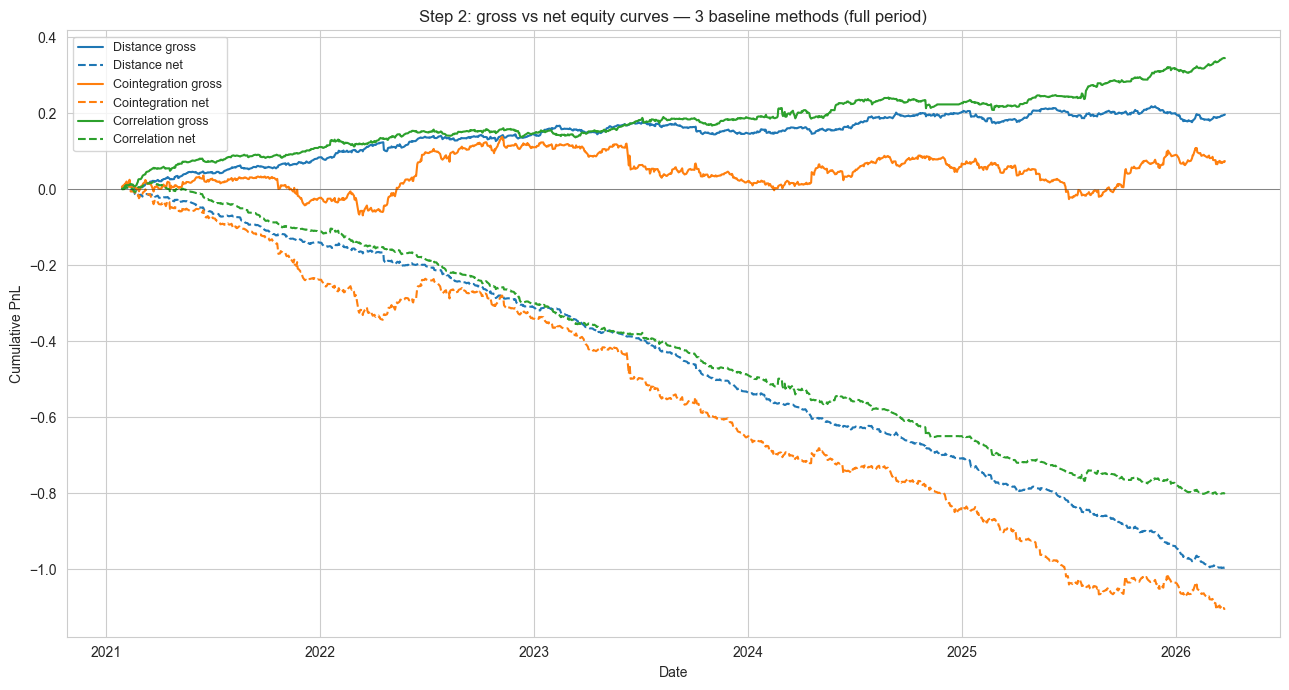

In [29]:
# Bloc 2.5 — Equity curves: gross vs net

fig, ax = plt.subplots(figsize=(13, 7))

for name, pnl, style in [
    ("Distance gross",      pnl_distance_gross, {"lw": 1.5, "ls": "-", "color": "tab:blue"}),
    ("Distance net",        pnl_distance_net,   {"lw": 1.5, "ls": "--", "color": "tab:blue"}),
    ("Cointegration gross", pnl_coint_gross,    {"lw": 1.5, "ls": "-", "color": "tab:orange"}),
    ("Cointegration net",   pnl_coint_net,      {"lw": 1.5, "ls": "--", "color": "tab:orange"}),
    ("Correlation gross",   pnl_correl_gross,   {"lw": 1.5, "ls": "-", "color": "tab:green"}),
    ("Correlation net",     pnl_correl_net,     {"lw": 1.5, "ls": "--", "color": "tab:green"}),
]:
    daily = pnl.groupby(pnl.index.date).sum()
    daily.index = pd.to_datetime(daily.index)
    cum = daily.cumsum()
    ax.plot(cum.index, cum.values, label=name, **style)

ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.set_ylabel("Cumulative PnL")
ax.set_xlabel("Date")
ax.set_title("Step 2: gross vs net equity curves — 3 baseline methods (full period)")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


## Step 3 — K-means rolling filter

Baseline methods (Step 1) select pairs from the full universe of tickers. 
Here we pre-filter tickers via **K-means clustering** on structural 
features (volatility, beta, market correlation, PCA components, sector 
one-hot), then restrict pair selection to **intra-cluster pairs only**.

### Key difference vs Sarmento & Horta (2020)

Sarmento et al. fit K-means **once** on the full training period. 
We instead fit K-means on a **rolling 252-day window**, re-fitted every 
10 walk-forward windows (~2.5 months). This guarantees zero look-ahead 
bias: at every point in the backtest, the cluster assignment uses only 
strictly past data.


In [30]:
# Bloc 3.1 — Sector mapping (GICS)

SECTOR_MAP = {
    # Tech
    "AAPL": "Tech", "MSFT": "Tech", "GOOGL": "Tech", "GOOG": "Tech",
    "AMZN": "Tech", "META": "Tech", "NVDA": "Tech", "TSLA": "Tech",
    "NFLX": "Tech", "ADBE": "Tech", "CRM": "Tech", "ORCL": "Tech",
    "INTC": "Tech", "AMD": "Tech", "CSCO": "Tech", "QCOM": "Tech",
    "IBM": "Tech", "TXN": "Tech", "AVGO": "Tech",
    
    # Finance
    "JPM": "Finance", "BAC": "Finance", "WFC": "Finance", "C": "Finance",
    "GS": "Finance", "MS": "Finance", "BLK": "Finance", "AXP": "Finance",
    "V": "Finance", "MA": "Finance", "SCHW": "Finance", "USB": "Finance",
    "PNC": "Finance",
    
    # Energy
    "XOM": "Energy", "CVX": "Energy", "COP": "Energy", "SLB": "Energy",
    "EOG": "Energy", "MPC": "Energy", "PSX": "Energy", "VLO": "Energy",
    "OXY": "Energy",
    
    # Health
    "JNJ": "Health", "PFE": "Health", "MRK": "Health", "ABBV": "Health",
    "LLY": "Health", "UNH": "Health", "BMY": "Health", "AMGN": "Health",
    "GILD": "Health", "CVS": "Health",
    
    # Consumer
    "HD": "Consumer", "LOW": "Consumer", "WMT": "Consumer", "TGT": "Consumer",
    "COST": "Consumer", "NKE": "Consumer", "MCD": "Consumer", "SBUX": "Consumer",
    "KO": "Consumer", "PEP": "Consumer", "PG": "Consumer", "CL": "Consumer",
    "MDLZ": "Consumer",
    
    # Industrial
    "BA": "Industrial", "CAT": "Industrial", "GE": "Industrial", "HON": "Industrial",
    "LMT": "Industrial", "RTX": "Industrial", "UPS": "Industrial", "FDX": "Industrial",
}

def get_sector(ticker):
    return SECTOR_MAP.get(ticker, "Other")

# Check coverage on retained tickers
retained = sorted(close_m1.columns)
sectors_in_use = {t: get_sector(t) for t in retained}

from collections import Counter
sector_counts = Counter(sectors_in_use.values())
print(f"Sector coverage over {len(retained)} retained tickers:")
for s, n in sector_counts.most_common():
    print(f"  {s:12} : {n:3d}")

unmapped = [t for t in retained if get_sector(t) == "Other"]
if unmapped:
    print(f"\nWARNING: {len(unmapped)} unmapped tickers: {unmapped}")


Sector coverage over 39 retained tickers:
  Tech         :  15
  Finance      :   7
  Consumer     :   6
  Health       :   5
  Energy       :   4
  Industrial   :   2


In [31]:
# Bloc 3.2 — Rolling feature builder

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def build_features_rolling(end_date, window_days=ROLLING_HISTORY):
    """Build K-means features using only data ending at end_date,
    looking back window_days trading days.
    
    Returns a standardized features DataFrame (tickers x features),
    or None if not enough data available.
    """
    start_date = end_date - pd.Timedelta(days=int(window_days * 1.5))  # calendar buffer
    
    prices_feat = close_m1.loc[start_date:end_date].dropna(axis=1, how="all")
    daily_feat  = close_daily.loc[start_date:end_date].dropna(axis=1, how="all")
    
    # Keep only last window_days of trading days
    trading_days_avail = daily_feat.dropna(how="all").index
    if len(trading_days_avail) < 60:
        return None
    if len(trading_days_avail) > window_days:
        cutoff = trading_days_avail[-window_days]
        prices_feat = prices_feat.loc[cutoff:]
        daily_feat  = daily_feat.loc[cutoff:]
    
    tickers_feat = sorted(set(prices_feat.columns) & set(daily_feat.columns))
    if len(tickers_feat) < 10:
        return None
    
    daily_returns = daily_feat[tickers_feat].pct_change().dropna()
    market_return = daily_returns.mean(axis=1)
    
    feat_rows = []
    for t in tickers_feat:
        m1_ret = prices_feat[t].pct_change().dropna()
        if len(m1_ret) < 100:
            continue
        vol_ann = m1_ret.std() * np.sqrt(380 * 252)
        
        dr = daily_returns[t]
        valid = dr.notna() & market_return.notna()
        if valid.sum() > 20:
            beta_mkt = np.cov(dr[valid], market_return[valid])[0, 1] / market_return[valid].var()
            corr_mkt = dr[valid].corr(market_return[valid])
        else:
            beta_mkt, corr_mkt = np.nan, np.nan
        
        feat_rows.append({
            "ticker":   t,
            "sector":   get_sector(t),
            "vol_ann":  vol_ann,
            "beta_mkt": beta_mkt,
            "corr_mkt": corr_mkt,
        })
    
    features_df = pd.DataFrame(feat_rows).set_index("ticker").dropna()
    if len(features_df) < 10:
        return None
    
    # PCA on daily returns
    tickers_kept = features_df.index.tolist()
    X_returns = daily_returns[tickers_kept].T.fillna(0)
    scaler_pca = StandardScaler()
    X_scaled = scaler_pca.fit_transform(X_returns.values)
    pca = PCA(n_components=min(3, X_scaled.shape[1]))
    pca_components = pca.fit_transform(X_scaled)
    
    for i, t in enumerate(tickers_kept):
        for j in range(pca_components.shape[1]):
            features_df.loc[t, f"pca{j+1}"] = pca_components[i, j]
    
    # One-hot encode sector
    sector_dummies = pd.get_dummies(features_df["sector"], prefix="sector")
    features_final = pd.concat([features_df.drop(columns="sector"), sector_dummies], axis=1)
    
    # Standardize
    scaler_feat = StandardScaler()
    features_scaled = pd.DataFrame(
        scaler_feat.fit_transform(features_final),
        index=features_final.index,
        columns=features_final.columns,
    )
    return features_scaled


# Test the function on the last available date (no look-ahead, just a dry run)
dry_end = close_daily.index[-1]
feat_test = build_features_rolling(dry_end)
if feat_test is not None:
    print(f"Dry run on {dry_end.date()}: features_scaled shape = {feat_test.shape}")
    print(f"Features columns: {list(feat_test.columns)}")
else:
    print("Dry run returned None — check window size")


C:\Users\pc\AppData\Local\Temp\ipykernel_17356\16936058.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  m1_ret = prices_feat[t].pct_change().dropna()


Dry run on 2026-03-30: features_scaled shape = (39, 12)
Features columns: ['vol_ann', 'beta_mkt', 'corr_mkt', 'pca1', 'pca2', 'pca3', 'sector_Consumer', 'sector_Energy', 'sector_Finance', 'sector_Health', 'sector_Industrial', 'sector_Tech']


K-selection reference date: 2021-12-31


C:\Users\pc\AppData\Local\Temp\ipykernel_17356\16936058.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  m1_ret = prices_feat[t].pct_change().dropna()


Features shape at ref_date: (39, 12)


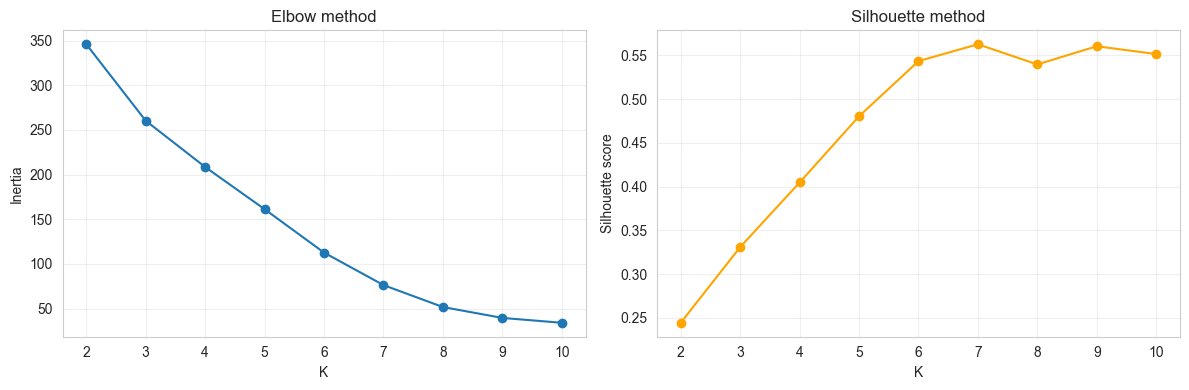


Best K by silhouette: 7 (silhouette=0.563)

Fixed K_FINAL = 7 (compromise between silhouette peak and interpretability)


In [32]:
# Bloc 3.3 — Choose K by elbow and silhouette

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reference date: use early in train period, not too close to test
# Take a date in the first half of train (after warmup is complete)
train_start_date = windows_all[WARMUP_WINDOWS][0][0]  # first traded window start
ref_date = train_start_date + pd.Timedelta(days=ROLLING_HISTORY + 100)

# Ensure ref_date is still in train
# Use a ref_date far enough from the end of sample for visualization
last_date = close_daily.index[-1]
if ref_date > last_date - pd.Timedelta(days=100):
    ref_date = last_date - pd.Timedelta(days=200)

print(f"K-selection reference date: {ref_date.date()}")
features_ref = build_features_rolling(ref_date)
print(f"Features shape at ref_date: {features_ref.shape}")

k_range = range(2, min(11, len(features_ref) // 3))
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_ref.values)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(features_ref.values, labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "-o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, "-o", color="orange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette method")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_silhouette.png", dpi=100, bbox_inches="tight")
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\nBest K by silhouette: {best_k} (silhouette={max(silhouettes):.3f})")

# Fixed K chosen based on both elbow and silhouette
K_FINAL = 7
print(f"\nFixed K_FINAL = {K_FINAL} (compromise between silhouette peak and interpretability)")


C:\Users\pc\AppData\Local\Temp\ipykernel_17356\16936058.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  m1_ret = prices_feat[t].pct_change().dropna()
C:\Users\pc\AppData\Local\Temp\ipykernel_17356\16936058.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  m1_ret = prices_feat[t].pct_change().dropna()
C:\Users\pc\AppData\Local\Temp\ipykernel_17356\16936058.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fi

Total K-means re-fits attempted: 31
Successful fits: 29
Warmup (None) fits: 2
First successful fit at window: 20


C:\Users\pc\AppData\Local\Temp\ipykernel_17356\16936058.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  m1_ret = prices_feat[t].pct_change().dropna()



Clustering at reference date (2021-12-31):

  Cluster 0 (2 tickers, sectors: {'Industrial': 2}):
    ['BA', 'GE']

  Cluster 1 (7 tickers, sectors: {'Finance': 7}):
    ['BAC', 'C', 'JPM', 'MS', 'USB', 'V', 'WFC']

  Cluster 2 (6 tickers, sectors: {'Consumer': 6}):
    ['KO', 'MDLZ', 'NKE', 'PEP', 'PG', 'SBUX']

  Cluster 3 (4 tickers, sectors: {'Energy': 4}):
    ['COP', 'CVX', 'SLB', 'XOM']

  Cluster 4 (14 tickers, sectors: {'Tech': 14}):
    ['AAPL', 'AMD', 'AMZN', 'AVGO', 'CSCO', 'GOOG', 'IBM', 'INTC', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'QCOM', 'TXN']

  Cluster 5 (5 tickers, sectors: {'Health': 5}):
    ['CVS', 'GILD', 'JNJ', 'MRK', 'UNH']

  Cluster 6 (1 tickers, sectors: {'Tech': 1}):
    ['TSLA']


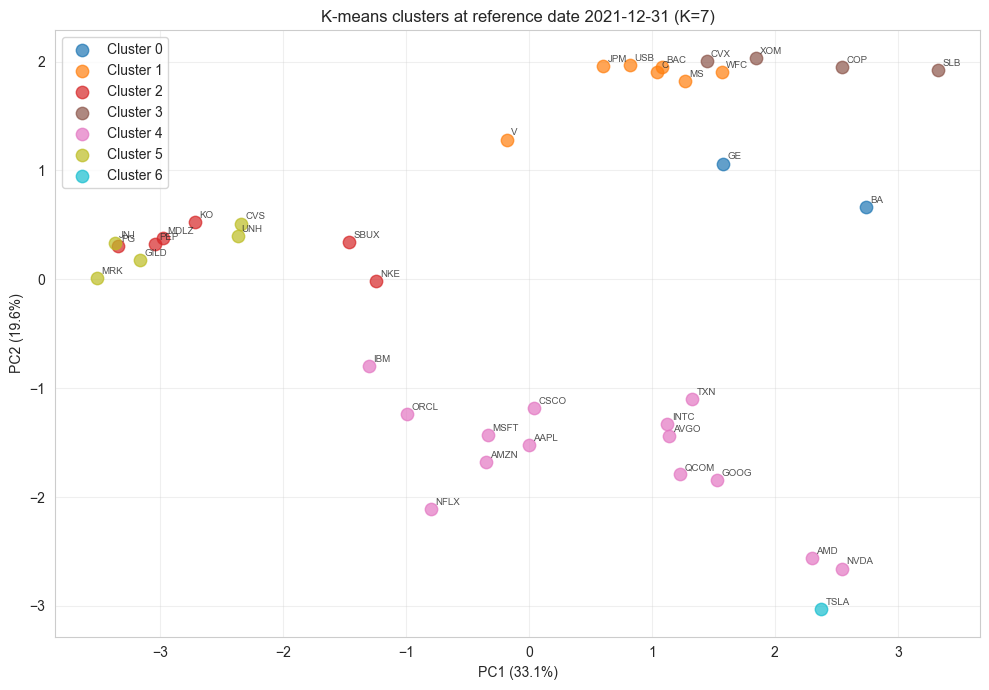

In [33]:
# Bloc 3.4 — Build rolling K-means cluster history

cluster_history = {}   # {refit_window_idx: ticker_cluster dict}

all_windows = windows  # all walk-forward windows (train + test concatenated)
n_refits_km = 0
for wi in range(0, len(all_windows), REFIT_EVERY):
    formation_start = all_windows[wi][0][0]
    end_date = formation_start - pd.Timedelta(days=1)  # strictly past
    feat = build_features_rolling(end_date)
    if feat is None:
        cluster_history[wi] = None
        continue
    km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
    labels = km.fit_predict(feat.values)
    tc = dict(zip(feat.index, labels))
    cluster_history[wi] = tc
    n_refits_km += 1

print(f"Total K-means re-fits attempted: {len(cluster_history)}")
print(f"Successful fits: {n_refits_km}")
print(f"Warmup (None) fits: {len(cluster_history) - n_refits_km}")
print(f"First successful fit at window: {next(wi for wi in sorted(cluster_history) if cluster_history[wi] is not None)}")


def get_cluster_for_window(window_idx):
    """Return the cluster mapping valid at window_idx. 
    Returns None if not enough past data (warmup period)."""
    valid_refits = sorted([k for k in cluster_history.keys() if k <= window_idx 
                           and cluster_history[k] is not None])
    if not valid_refits:
        return None  # warmup: no filter available
    return cluster_history[valid_refits[-1]]


# Visualize clusters at reference date
feat_ref = build_features_rolling(ref_date)
km_ref = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels_ref = km_ref.fit_predict(feat_ref.values)
ticker_cluster_ref = dict(zip(feat_ref.index, labels_ref))

print(f"\nClustering at reference date ({ref_date.date()}):")
for c in range(K_FINAL):
    members = sorted([t for t, cl in ticker_cluster_ref.items() if cl == c])
    sectors_in_cluster = Counter(get_sector(t) for t in members)
    print(f"\n  Cluster {c} ({len(members)} tickers, sectors: {dict(sectors_in_cluster)}):")
    print(f"    {members}")

# 2D PCA visualization
pca_viz = PCA(n_components=2)
pts = pca_viz.fit_transform(feat_ref.values)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, K_FINAL))
for c in range(K_FINAL):
    mask = labels_ref == c
    ax.scatter(pts[mask, 0], pts[mask, 1], label=f"Cluster {c}",
               s=80, alpha=0.7, color=colors[c])
    for t, (x, y) in zip(feat_ref.index[mask], pts[mask]):
        ax.annotate(t, (x, y), fontsize=7, alpha=0.8, xytext=(3, 3),
                   textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"K-means clusters at reference date {ref_date.date()} (K={K_FINAL})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_kmeans_clusters.png", dpi=100, bbox_inches="tight")
plt.show()


In [34]:
# Bloc 3.5 — Intra-cluster pair selection wrappers

def select_pairs_distance_intracluster(formation_days, close_m1, day_flags, 
                                        ticker_cluster, top_n=10):
    """Distance method restricted to intra-cluster pairs."""
    pairs = select_pairs_distance(formation_days, close_m1, day_flags, top_n=top_n*5)
    intra = [(a, b, d) for (a, b, d) in pairs 
             if ticker_cluster.get(a) is not None 
             and ticker_cluster.get(a) == ticker_cluster.get(b)]
    return intra[:top_n]


def select_pairs_cointegration_intracluster(formation_days, close_m1, day_flags,
                                              ticker_cluster, top_n=10, pvalue_max=0.05):
    """Cointegration method restricted to intra-cluster pairs."""
    pairs = select_pairs_cointegration(formation_days, close_m1, day_flags,
                                        top_n=top_n*5, pvalue_max=pvalue_max)
    intra = [(a, b, p) for (a, b, p) in pairs 
             if ticker_cluster.get(a) is not None 
             and ticker_cluster.get(a) == ticker_cluster.get(b)]
    return intra[:top_n]


def select_pairs_correlation_intracluster(formation_days, close_m1, day_flags,
                                            ticker_cluster, top_n=10, corr_min=0.70):
    """Correlation method restricted to intra-cluster pairs."""
    pairs = select_pairs_correlation(formation_days, close_m1, day_flags,
                                      top_n=top_n*5, corr_min=corr_min)
    intra = [(a, b, c) for (a, b, c) in pairs 
             if ticker_cluster.get(a) is not None 
             and ticker_cluster.get(a) == ticker_cluster.get(b)]
    return intra[:top_n]


# Quick test on the reference date cluster mapping
first_tw = windows_all[WARMUP_WINDOWS]  # first traded window
formation_days_test = first_tw[0]
pairs_d = select_pairs_distance_intracluster(formation_days_test, close_m1, day_flags,
                                              ticker_cluster_ref, top_n=TOP_N)
print(f"Intra-cluster distance pairs on first train window: {len(pairs_d)}")
for a, b, d in pairs_d[:5]:
    print(f"  {a} - {b} | distance = {d:.4f} | cluster = {ticker_cluster_ref[a]}")


Intra-cluster distance pairs on first train window: 10
  MDLZ - PEP | distance = 0.3516 | cluster = 2
  CVX - XOM | distance = 0.4311 | cluster = 3
  CSCO - ORCL | distance = 0.5166 | cluster = 4
  CVS - MRK | distance = 0.5953 | cluster = 5
  BAC - WFC | distance = 0.6468 | cluster = 1


In [35]:
# Bloc 3.6 — Backtest loop: 3 K-means methods

def run_backtest_kmeans(windows_subset, offset, label):
    """Run K-means filtered backtest with net costs.
    
    `offset` is the global window index of the first window in windows_subset.
    Windows where get_cluster_for_window returns None are skipped.
    """
    pnl_dg, pnl_dn = [], []
    pnl_cg, pnl_cn = [], []
    pnl_rg, pnl_rn = [], []
    pairs_log_rows = []
    skipped = 0
    traded = 0
    t0 = time.time()
    
    for i, (formation_days, trading_days) in enumerate(windows_subset):
        global_wi = offset + i
        if i % 20 == 0:
            print(f"  [{label}] Window {i}/{len(windows_subset)}  ({time.time()-t0:.0f}s)")
        
        # Uniform warmup: skip first WARMUP_WINDOWS GLOBAL windows for fair comparison with baselines
        # Using global_wi (not local i) is critical: we want the FIRST 50 windows of the whole 
        # backtest skipped, not the first 50 of each train/test subset separately.
        if global_wi < WARMUP_WINDOWS:
            skipped += 1
            continue
        
        tc = get_cluster_for_window(global_wi)
        if tc is None:
            skipped += 1
            continue  # no filter available yet (warmup)
        
        traded += 1
        pairs_dist  = select_pairs_distance_intracluster(formation_days, close_m1, day_flags,
                                                          tc, top_n=TOP_N)
        pairs_coint = select_pairs_cointegration_intracluster(formation_days, close_m1, day_flags,
                                                                tc, top_n=TOP_N, pvalue_max=PVALUE_MAX)
        pairs_corr  = select_pairs_correlation_intracluster(formation_days, close_m1, day_flags,
                                                              tc, top_n=TOP_N, corr_min=CORR_MIN)
        
        for method_name, pair_list, bucket_g, bucket_n in [
            ("kmeans+distance",      pairs_dist,  pnl_dg, pnl_dn),
            ("kmeans+cointegration", pairs_coint, pnl_cg, pnl_cn),
            ("kmeans+correlation",   pairs_corr,  pnl_rg, pnl_rn),
        ]:
            pair_g, pair_n = [], []
            for (a, b, score) in pair_list:
                alpha, beta = compute_hedge_ratio(formation_days, a, b, close_m1, day_flags)
                spread, z, position = generate_signals(
                    formation_days, trading_days, a, b, beta, close_m1, k=K_THRESHOLD
                )
                pnl_beta = beta if "cointegration" in method_name else None
                pg, pn = compute_pair_pnl_net(position, a, b, close_m1, trading_days, beta=pnl_beta)
                pair_g.append(pg)
                pair_n.append(pn)
                n_halfturns = int((position.diff().fillna(0).abs() > 0).sum())
                pairs_log_rows.append({
                    "period":        label,
                    "window_idx":    global_wi,
                    "trading_start": trading_days[0],
                    "method":        method_name,
                    "ticker_a": a, "ticker_b": b,
                    "score": score, "beta": beta,
                    "pair_gross_pnl": pg.sum(),
                    "pair_net_pnl":   pn.sum(),
                    "pair_n_halfturns": n_halfturns,
                })
            if pair_g:
                bucket_g.append(pd.concat(pair_g, axis=1).mean(axis=1))
                bucket_n.append(pd.concat(pair_n, axis=1).mean(axis=1))
    
    print(f"  [{label}] traded {traded}, skipped {skipped} (warmup)")
    return {
        "gross": {
            "kmeans+distance":      pd.concat(pnl_dg).sort_index() if pnl_dg else pd.Series(dtype=float),
            "kmeans+cointegration": pd.concat(pnl_cg).sort_index() if pnl_cg else pd.Series(dtype=float),
            "kmeans+correlation":   pd.concat(pnl_rg).sort_index() if pnl_rg else pd.Series(dtype=float),
        },
        "net": {
            "kmeans+distance":      pd.concat(pnl_dn).sort_index() if pnl_dn else pd.Series(dtype=float),
            "kmeans+cointegration": pd.concat(pnl_cn).sort_index() if pnl_cn else pd.Series(dtype=float),
            "kmeans+correlation":   pd.concat(pnl_rn).sort_index() if pnl_rn else pd.Series(dtype=float),
        },
        "pairs_log": pd.DataFrame(pairs_log_rows),
    }


# No train/test split: single full-period backtest

print("=== FULL PERIOD (rolling K-means) ===")
result_km = run_backtest_kmeans(windows_all, offset=0, label="full")


=== FULL PERIOD (rolling K-means) ===
  [full] Window 0/309  (0s)
  [full] Window 20/309  (0s)
  [full] Window 40/309  (0s)
  [full] Window 60/309  (21s)
  [full] Window 80/309  (62s)
  [full] Window 100/309  (103s)
  [full] Window 120/309  (144s)
  [full] Window 140/309  (184s)
  [full] Window 160/309  (224s)
  [full] Window 180/309  (264s)
  [full] Window 200/309  (305s)
  [full] Window 220/309  (343s)
  [full] Window 240/309  (384s)
  [full] Window 260/309  (421s)
  [full] Window 280/309  (460s)
  [full] Window 300/309  (500s)
  [full] traded 259, skipped 50 (warmup)


In [36]:
# Bloc 3.7 — Performance comparison: K-means vs baseline

def compute_metrics(pnl_series):
    """Compute Sharpe, Sortino, MaxDD from M1 PnL series."""
    if len(pnl_series) == 0:
        return {"total_pnl": 0, "sharpe": np.nan, "sortino": np.nan, "max_dd": np.nan}
    daily = pnl_series.groupby(pnl_series.index.date).sum()
    if len(daily) < 10:
        return {"total_pnl": daily.sum(), "sharpe": np.nan, "sortino": np.nan, "max_dd": np.nan}
    mean_d, std_d = daily.mean(), daily.std()
    sharpe = mean_d / std_d * np.sqrt(252) if std_d > 0 else np.nan
    neg = daily[daily < 0]
    sortino = mean_d / neg.std() * np.sqrt(252) if len(neg) > 1 else np.nan
    cum = daily.cumsum()
    dd = (cum - cum.cummax()).min()
    return {"total_pnl": daily.sum(), "sharpe": sharpe, "sortino": sortino, "max_dd": dd}


rows = []
# Baselines (from Step 2, full period)
for m, pnl in result_costs["net"].items():
    mt = compute_metrics(pnl)
    rows.append({
        "method": m,
        "sharpe": mt["sharpe"],
        "total_pnl": mt["total_pnl"],
        "max_dd": mt["max_dd"],
    })
# K-means methods (full period)
for m, pnl in result_km["net"].items():
    mt = compute_metrics(pnl)
    rows.append({
        "method": m,
        "sharpe": mt["sharpe"],
        "total_pnl": mt["total_pnl"],
        "max_dd": mt["max_dd"],
    })

compare_km = pd.DataFrame(rows).set_index("method").round(3)
# Order: baseline first, then K-means
ordered = ["distance", "cointegration", "correlation",
           "kmeans+distance", "kmeans+cointegration", "kmeans+correlation"]
compare_km = compare_km.reindex([m for m in ordered if m in compare_km.index])

print("=" * 80)
print("K-means vs baseline performance comparison (net of costs, full period)")
print("=" * 80)
print(compare_km)


K-means vs baseline performance comparison (net of costs, full period)
                      sharpe  total_pnl  max_dd
method                                         
distance              -6.005     -0.996  -1.004
cointegration         -2.871     -1.103  -1.120
correlation           -4.236     -0.802  -0.822
kmeans+distance       -6.246     -0.930  -0.934
kmeans+cointegration  -1.475     -0.799  -0.937
kmeans+correlation    -4.636     -0.825  -0.845


## Step 4 — Autoencoder rolling filter (Jung 2024, Approach B)

K-means provides a coarse sectoral filter. The autoencoder (AE) adds a
**fine-grained, learned notion of similarity**: it compresses each 
ticker's recent return dynamics into a latent vector, and we define a 
ticker's "neighborhood" as its **k nearest neighbors** in this latent 
space (Euclidean distance).

### Key design choices

- **Input**: `ROLLING_DAYS_AE`-day rolling returns (parameterized; default 60)
- **Architecture**: 128-unit hidden layer, ReLU, L2 = 1e-4, dropout = 0.1
- **Latent dimension**: chosen via PCA 95% variance rule at reference date
- **Neighborhood size**: k = 7
- **Rolling re-fit**: every 10 windows on the preceding `ROLLING_HISTORY` days (default 252)

### Key difference vs Jung (2024)

Jung trains the autoencoder **once** on the full training set and freezes
the neighborhoods throughout the backtest. We instead **re-fit the AE 
every 2.5 months** on a rolling 1-year window, ensuring zero look-ahead 
bias and allowing the latent space to adapt to regime changes.


Reference input matrix: (39, 192) (tickers x days)
Latent dim chosen (95% variance): 8


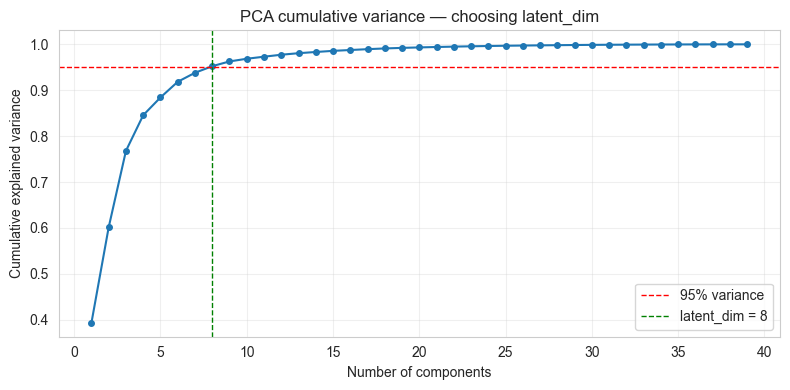

In [37]:
# Bloc 4.1 — Latent dimension selection

start_ref = ref_date - pd.Timedelta(days=int(ROLLING_HISTORY * 1.5))
daily_ref = close_daily.loc[start_ref:ref_date].dropna(axis=1, how="all")
trading_avail = daily_ref.dropna(how="all").index
if len(trading_avail) > ROLLING_HISTORY:
    cutoff = trading_avail[-ROLLING_HISTORY]
    daily_ref = daily_ref.loc[cutoff:]

# Rolling 60-day returns
rolling_ret_ref = daily_ref.pct_change(periods=ROLLING_DAYS_AE).dropna(how="all")
X_ref = rolling_ret_ref.dropna().T  # (tickers, days)

print(f"Reference input matrix: {X_ref.shape} (tickers x days)")

# PCA to find 95% variance
scaler_ae = StandardScaler()
X_ref_scaled = scaler_ae.fit_transform(X_ref.values)

pca_ae = PCA()
pca_ae.fit(X_ref_scaled)
cumvar = np.cumsum(pca_ae.explained_variance_ratio_)
latent_dim = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Latent dim chosen (95% variance): {latent_dim}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, "-o", markersize=4)
ax.axhline(0.95, color="red", ls="--", lw=1, label="95% variance")
ax.axvline(latent_dim, color="green", ls="--", lw=1, label=f"latent_dim = {latent_dim}")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative variance — choosing latent_dim")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_pca_variance.png", dpi=100, bbox_inches="tight")
plt.show()


Training test AE on reference date 2021-12-31...
Neighbors computed for 39 tickers


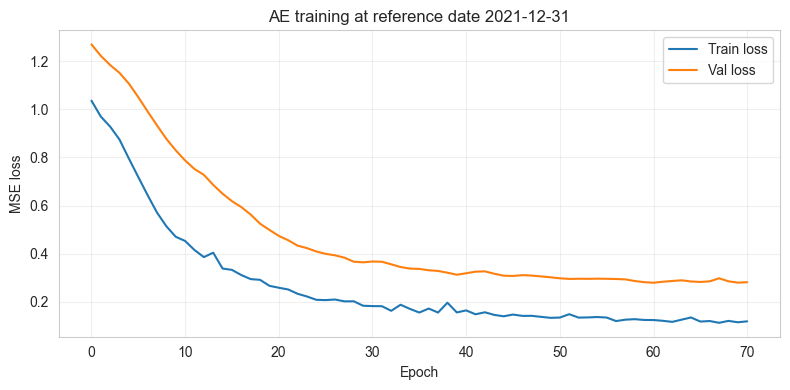

Stopped at epoch 71
Final train loss: 0.1186
Final val loss:   0.2813


In [38]:
# Bloc 4.2 — Rolling autoencoder fit function

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from tensorflow import keras
from tensorflow.keras import layers, regularizers
import tensorflow as tf
from sklearn.neighbors import NearestNeighbors


def fit_autoencoder_rolling(end_date, window_days=ROLLING_HISTORY, 
                             lookback_days=ROLLING_DAYS_AE, k_nn=7,
                             min_obs_ae=30, hidden_units=128, l2_reg=1e-4,
                             dropout_rate=0.1, return_history=False):
    """Fit autoencoder + NN on rolling history ending at end_date.
    
    Returns ticker_neighbors dict, or None if not enough data.
    If return_history=True, also returns training history.
    """
    start_date = end_date - pd.Timedelta(days=int(window_days * 1.5))
    
    train_daily_roll = close_daily.loc[start_date:end_date].dropna(axis=1, how="all")
    
    if len(train_daily_roll) > window_days:
        train_daily_roll = train_daily_roll.iloc[-window_days:]
    
    if len(train_daily_roll) < lookback_days + min_obs_ae:
        return None if not return_history else (None, None)
    
    rolling_ret = train_daily_roll.pct_change(periods=lookback_days).dropna(how="all")
    X_roll = rolling_ret.dropna().T  # (tickers, days)
    
    if X_roll.shape[0] < 15 or X_roll.shape[1] < min_obs_ae:
        return None if not return_history else (None, None)
    
    scaler_ae_r = StandardScaler()
    X_roll_scaled = scaler_ae_r.fit_transform(X_roll.values)
    
    input_dim = X_roll_scaled.shape[1]
    
    tf.random.set_seed(42)
    np.random.seed(42)
    
    enc_in = keras.Input(shape=(input_dim,))
    x = layers.Dense(hidden_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_reg))(enc_in)
    x = layers.Dropout(dropout_rate)(x)
    lat = layers.Dense(latent_dim, activation="linear")(x)
    x = layers.Dense(hidden_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_reg))(lat)
    x = layers.Dropout(dropout_rate)(x)
    dec_out = layers.Dense(input_dim, activation="linear")(x)
    
    ae_r = keras.Model(enc_in, dec_out)
    enc_r = keras.Model(enc_in, lat)
    ae_r.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                        restore_best_weights=True)
    history = ae_r.fit(X_roll_scaled, X_roll_scaled,
                       epochs=100, batch_size=8, validation_split=0.2,
                       callbacks=[es], verbose=0)
    
    latents = enc_r.predict(X_roll_scaled, verbose=0)
    tickers_idx = X_roll.index.tolist()
    
    k_eff = min(k_nn + 1, len(tickers_idx))
    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(latents)
    _, idx_nn = nn.kneighbors(latents)
    
    ticker_neighbors_r = {}
    for i, t in enumerate(tickers_idx):
        neighbor_tickers = [tickers_idx[j] for j in idx_nn[i][1:]]
        ticker_neighbors_r[t] = set(neighbor_tickers)
    
    if return_history:
        return ticker_neighbors_r, history
    return ticker_neighbors_r


# Quick test: fit on reference date
print(f"Training test AE on reference date {ref_date.date()}...")
nn_ref, hist_ref = fit_autoencoder_rolling(ref_date, return_history=True)
if nn_ref is not None:
    print(f"Neighbors computed for {len(nn_ref)} tickers")
    # Plot training curves
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hist_ref.history["loss"], label="Train loss")
    ax.plot(hist_ref.history["val_loss"], label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(f"AE training at reference date {ref_date.date()}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig_ae_training.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Stopped at epoch {len(hist_ref.history['loss'])}")
    print(f"Final train loss: {hist_ref.history['loss'][-1]:.4f}")
    print(f"Final val loss:   {hist_ref.history['val_loss'][-1]:.4f}")
else:
    print("Not enough data at reference date")


In [39]:
# Bloc 4.3 — Build rolling AE neighbor history

print("Building rolling AE history (window=252d, lookback=60d, refit every 10w)...")
t_ae_start = time.time()
neighbor_history = {}

for wi in range(0, len(all_windows), REFIT_EVERY):
    formation_start = all_windows[wi][0][0]
    end_date = formation_start - pd.Timedelta(days=1)
    nn_map = fit_autoencoder_rolling(end_date)
    neighbor_history[wi] = nn_map
    n_tickers = len(nn_map) if nn_map is not None else 0
    status = f"AE fit on {n_tickers} tickers" if nn_map else "NOT ENOUGH DATA (warmup)"
    elapsed = time.time() - t_ae_start
    print(f"  Window {wi:3d} (formation starts {formation_start.date()}): {status}  [{elapsed:.0f}s]")

n_refits_ae = sum(1 for v in neighbor_history.values() if v is not None)
print(f"\nTotal successful AE re-fits: {n_refits_ae} / {len(neighbor_history)}")
print(f"Warmup windows (no filter): {len(neighbor_history) - n_refits_ae}")
print(f"Total AE refit time: {time.time() - t_ae_start:.0f}s")


def get_neighbors_for_window(window_idx):
    """Return the neighbor mapping valid at window_idx, or None in warmup."""
    valid_refits = sorted([k for k in neighbor_history.keys() if k <= window_idx
                           and neighbor_history[k] is not None])
    if not valid_refits:
        return None
    return neighbor_history[valid_refits[-1]]


Building rolling AE history (window=252d, lookback=60d, refit every 10w)...
  Window   0 (formation starts 2020-01-16): NOT ENOUGH DATA (warmup)  [0s]
  Window  10 (formation starts 2020-03-30): NOT ENOUGH DATA (warmup)  [0s]
  Window  20 (formation starts 2020-06-10): AE fit on 39 tickers  [11s]
  Window  30 (formation starts 2020-08-20): AE fit on 39 tickers  [19s]
  Window  40 (formation starts 2020-10-30): AE fit on 39 tickers  [24s]
  Window  50 (formation starts 2021-01-13): AE fit on 39 tickers  [30s]
  Window  60 (formation starts 2021-03-26): AE fit on 39 tickers  [39s]
  Window  70 (formation starts 2021-06-08): AE fit on 39 tickers  [45s]
  Window  80 (formation starts 2021-08-18): AE fit on 39 tickers  [56s]
  Window  90 (formation starts 2021-10-28): AE fit on 39 tickers  [67s]
  Window 100 (formation starts 2022-01-10): AE fit on 39 tickers  [78s]
  Window 110 (formation starts 2022-03-23): AE fit on 39 tickers  [86s]
  Window 120 (formation starts 2022-06-03): AE fit on 

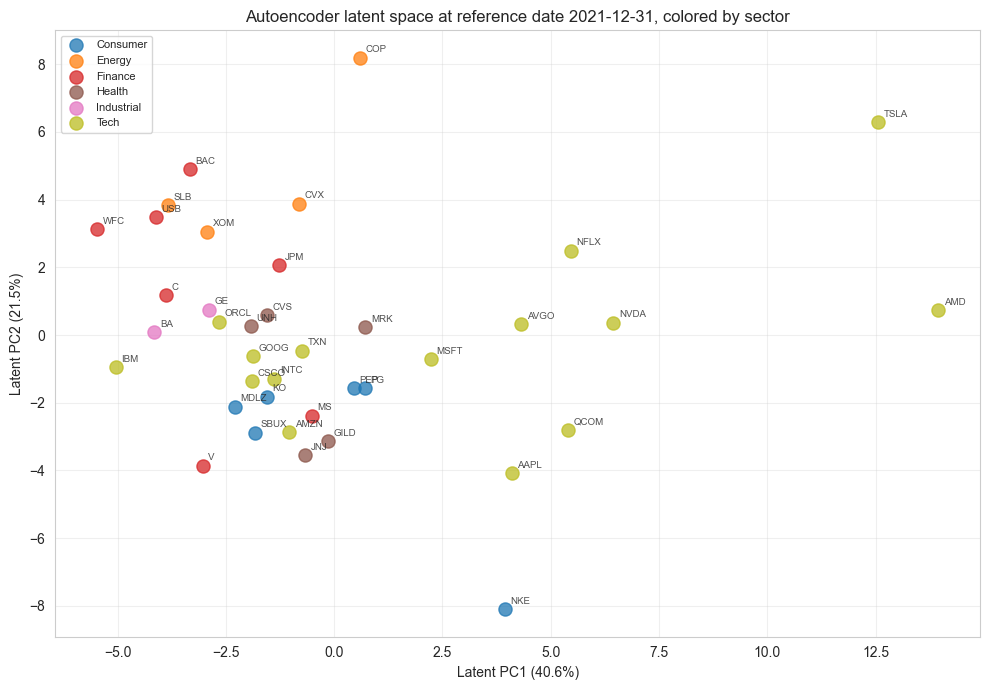

In [40]:
# Bloc 4.4 — Latent space visualization

from matplotlib.patches import Patch

# Re-fit at reference date to extract latents
start_ref = ref_date - pd.Timedelta(days=int(ROLLING_HISTORY * 1.5))
daily_ref = close_daily.loc[start_ref:ref_date].dropna(axis=1, how="all")
trading_avail = daily_ref.dropna(how="all").index
if len(trading_avail) > ROLLING_HISTORY:
    cutoff = trading_avail[-ROLLING_HISTORY]
    daily_ref = daily_ref.loc[cutoff:]
rolling_ret_ref = daily_ref.pct_change(periods=ROLLING_DAYS_AE).dropna(how="all")
X_ref = rolling_ret_ref.dropna().T

scaler_ae_ref = StandardScaler()
X_ref_scaled = scaler_ae_ref.fit_transform(X_ref.values)

tf.random.set_seed(42)
np.random.seed(42)
input_dim = X_ref_scaled.shape[1]
enc_in = keras.Input(shape=(input_dim,))
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(enc_in)
x = layers.Dropout(0.1)(x)
lat = layers.Dense(latent_dim, activation="linear")(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(lat)
x = layers.Dropout(0.1)(x)
dec_out = layers.Dense(input_dim, activation="linear")(x)

ae_ref = keras.Model(enc_in, dec_out)
enc_ref = keras.Model(enc_in, lat)
ae_ref.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
es_ref = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
ae_ref.fit(X_ref_scaled, X_ref_scaled, epochs=100, batch_size=8, validation_split=0.2,
           callbacks=[es_ref], verbose=0)
latents_ref = enc_ref.predict(X_ref_scaled, verbose=0)

# PCA to 2D
pca_lat = PCA(n_components=2)
latents_2d = pca_lat.fit_transform(latents_ref)

# Color by sector
tickers_idx = X_ref.index.tolist()
sectors_list = [get_sector(t) for t in tickers_idx]
unique_sectors = sorted(set(sectors_list))
sector_colors = {s: plt.cm.tab10(i / len(unique_sectors)) for i, s in enumerate(unique_sectors)}

fig, ax = plt.subplots(figsize=(10, 7))
for s in unique_sectors:
    mask = [sec == s for sec in sectors_list]
    coords = latents_2d[mask]
    ax.scatter(coords[:, 0], coords[:, 1], label=s, s=90, alpha=0.75,
               color=sector_colors[s])
for i, t in enumerate(tickers_idx):
    ax.annotate(t, latents_2d[i], fontsize=7, alpha=0.8, xytext=(4, 4),
                textcoords="offset points")

ax.set_xlabel(f"Latent PC1 ({pca_lat.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Latent PC2 ({pca_lat.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"Autoencoder latent space at reference date {ref_date.date()}, colored by sector")
ax.legend(loc="best", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_latent_space.png", dpi=100, bbox_inches="tight")
plt.show()


In [41]:
# Bloc 4.5 — AE neighbor pair selection wrappers

def are_neighbors(a, b, ticker_neighbors):
    """Check if a and b are mutual or one-way neighbors."""
    na = ticker_neighbors.get(a, set())
    nb = ticker_neighbors.get(b, set())
    return (b in na) or (a in nb)


def select_pairs_distance_ae(formation_days, close_m1, day_flags, 
                              ticker_neighbors, top_n=10):
    pairs = select_pairs_distance(formation_days, close_m1, day_flags, top_n=top_n*5)
    ok = [(a, b, d) for (a, b, d) in pairs if are_neighbors(a, b, ticker_neighbors)]
    return ok[:top_n]


def select_pairs_cointegration_ae(formation_days, close_m1, day_flags,
                                    ticker_neighbors, top_n=10, pvalue_max=0.05):
    pairs = select_pairs_cointegration(formation_days, close_m1, day_flags,
                                        top_n=top_n*5, pvalue_max=pvalue_max)
    ok = [(a, b, p) for (a, b, p) in pairs if are_neighbors(a, b, ticker_neighbors)]
    return ok[:top_n]


def select_pairs_correlation_ae(formation_days, close_m1, day_flags,
                                  ticker_neighbors, top_n=10, corr_min=0.70):
    pairs = select_pairs_correlation(formation_days, close_m1, day_flags,
                                      top_n=top_n*5, corr_min=corr_min)
    ok = [(a, b, c) for (a, b, c) in pairs if are_neighbors(a, b, ticker_neighbors)]
    return ok[:top_n]


# Quick sanity check
if nn_ref is not None:
    pairs_d_ae = select_pairs_distance_ae(windows_all[WARMUP_WINDOWS][0], close_m1, day_flags,
                                           nn_ref, top_n=TOP_N)
    print(f"AE distance pairs on first train window: {len(pairs_d_ae)}")
    for a, b, d in pairs_d_ae[:5]:
        print(f"  {a} - {b} | distance = {d:.4f}")


AE distance pairs on first train window: 10
  MDLZ - PEP | distance = 0.3516
  CVX - XOM | distance = 0.4311
  CSCO - ORCL | distance = 0.5166
  CVS - MRK | distance = 0.5953
  SBUX - TXN | distance = 0.6144


In [42]:
# Bloc 4.6 — Full backtest: 9 methods with rolling ML filters

method_configs = {
    "distance":             lambda fd, wi: select_pairs_distance(fd, close_m1, day_flags, top_n=TOP_N),
    "cointegration":        lambda fd, wi: select_pairs_cointegration(fd, close_m1, day_flags,
                                                                        top_n=TOP_N, pvalue_max=PVALUE_MAX),
    "correlation":          lambda fd, wi: select_pairs_correlation(fd, close_m1, day_flags,
                                                                     top_n=TOP_N, corr_min=CORR_MIN),
    "kmeans+distance":      lambda fd, wi: select_pairs_distance_intracluster(
                                fd, close_m1, day_flags, get_cluster_for_window(wi), top_n=TOP_N
                            ) if get_cluster_for_window(wi) is not None else [],
    "kmeans+cointegration": lambda fd, wi: select_pairs_cointegration_intracluster(
                                fd, close_m1, day_flags, get_cluster_for_window(wi),
                                top_n=TOP_N, pvalue_max=PVALUE_MAX
                            ) if get_cluster_for_window(wi) is not None else [],
    "kmeans+correlation":   lambda fd, wi: select_pairs_correlation_intracluster(
                                fd, close_m1, day_flags, get_cluster_for_window(wi),
                                top_n=TOP_N, corr_min=CORR_MIN
                            ) if get_cluster_for_window(wi) is not None else [],
    "ae+distance":          lambda fd, wi: select_pairs_distance_ae(
                                fd, close_m1, day_flags, get_neighbors_for_window(wi), top_n=TOP_N
                            ) if get_neighbors_for_window(wi) is not None else [],
    "ae+cointegration":     lambda fd, wi: select_pairs_cointegration_ae(
                                fd, close_m1, day_flags, get_neighbors_for_window(wi),
                                top_n=TOP_N, pvalue_max=PVALUE_MAX
                            ) if get_neighbors_for_window(wi) is not None else [],
    "ae+correlation":       lambda fd, wi: select_pairs_correlation_ae(
                                fd, close_m1, day_flags, get_neighbors_for_window(wi),
                                top_n=TOP_N, corr_min=CORR_MIN
                            ) if get_neighbors_for_window(wi) is not None else [],
}


def run_backtest_full(windows_subset, offset, label):
    """Run all 9 methods together. Windows where ML filters are unavailable 
    (warmup) are skipped for all methods to ensure fair comparison."""
    pnl_gross = {m: [] for m in method_configs}
    pnl_net = {m: [] for m in method_configs}
    pairs_rows = []
    skipped = 0
    traded = 0
    t0 = time.time()
    
    for i, (formation_days, trading_days) in enumerate(windows_subset):
        global_wi = offset + i
        if i % 20 == 0:
            print(f"  [{label}] Window {i}/{len(windows_subset)}  ({time.time()-t0:.0f}s)")
        
        # Uniform warmup: skip first WARMUP_WINDOWS GLOBAL windows for fair comparison with baselines
        # Using global_wi (not local i) is critical: we want the FIRST 50 windows of the whole 
        # backtest skipped, not the first 50 of each train/test subset separately.
        if global_wi < WARMUP_WINDOWS:
            skipped += 1
            continue
        
        # Also skip if ML filters not yet available (should not happen after warmup, but safety)
        if get_cluster_for_window(global_wi) is None or get_neighbors_for_window(global_wi) is None:
            skipped += 1
            continue
        traded += 1
        
        for m_name, select_fn in method_configs.items():
            pair_list = select_fn(formation_days, global_wi)
            pair_g, pair_n = [], []
            for (a, b, score) in pair_list:
                alpha, beta = compute_hedge_ratio(formation_days, a, b, close_m1, day_flags)
                spread, z, position = generate_signals(
                    formation_days, trading_days, a, b, beta, close_m1, k=K_THRESHOLD
                )
                pnl_beta = beta if "cointegration" in m_name else None
                pg, pn = compute_pair_pnl_net(position, a, b, close_m1, trading_days, beta=pnl_beta)
                pair_g.append(pg)
                pair_n.append(pn)
                n_halfturns = int((position.diff().fillna(0).abs() > 0).sum())
                pairs_rows.append({
                    "period": label, "window_idx": global_wi, "method": m_name,
                    "trading_start": trading_days[0],
                    "ticker_a": a, "ticker_b": b, "score": score, "beta": beta,
                    "pair_gross_pnl": pg.sum(), "pair_net_pnl": pn.sum(),
                    "pair_n_halfturns": n_halfturns,
                })
            if pair_g:
                pnl_gross[m_name].append(pd.concat(pair_g, axis=1).mean(axis=1))
                pnl_net[m_name].append(pd.concat(pair_n, axis=1).mean(axis=1))
    
    print(f"  [{label}] traded {traded}, skipped {skipped} (warmup)")
    return {
        "gross": {m: pd.concat(v).sort_index() if v else pd.Series(dtype=float)
                  for m, v in pnl_gross.items()},
        "net":   {m: pd.concat(v).sort_index() if v else pd.Series(dtype=float)
                  for m, v in pnl_net.items()},
        "pairs_log": pd.DataFrame(pairs_rows),
    }


print("\n=== FULL PERIOD (rolling, 9 methods) ===")
result_full = run_backtest_full(windows_all, offset=0, label="full")



=== FULL PERIOD (rolling, 9 methods) ===
  [full] Window 0/309  (0s)
  [full] Window 20/309  (0s)
  [full] Window 40/309  (0s)
  [full] Window 60/309  (66s)
  [full] Window 80/309  (192s)
  [full] Window 100/309  (315s)
  [full] Window 120/309  (443s)
  [full] Window 140/309  (569s)
  [full] Window 160/309  (691s)
  [full] Window 180/309  (813s)
  [full] Window 200/309  (934s)
  [full] Window 220/309  (1050s)
  [full] Window 240/309  (1166s)
  [full] Window 260/309  (1283s)
  [full] Window 280/309  (1406s)
  [full] Window 300/309  (1522s)
  [full] traded 259, skipped 50 (warmup)


In [43]:
# Bloc 4.7 — Performance comparison across 9 methods (gross + net)

def compute_full_metrics(pnl_series):
    if len(pnl_series) == 0:
        return None
    daily = pnl_series.groupby(pnl_series.index.date).sum()
    if len(daily) < 10:
        return None
    mean_d, std_d = daily.mean(), daily.std()
    sharpe = mean_d / std_d * np.sqrt(252) if std_d > 0 else np.nan
    neg = daily[daily < 0]
    sortino = mean_d / neg.std() * np.sqrt(252) if len(neg) > 1 else np.nan
    cum = daily.cumsum()
    dd = (cum - cum.cummax()).min()
    ann_ret = mean_d * 252
    calmar = ann_ret / abs(dd) if dd < 0 else np.nan
    win_rate = (daily > 0).sum() / (daily != 0).sum() if (daily != 0).sum() > 0 else np.nan
    return {
        "total_pnl": daily.sum(), "sharpe": sharpe, "sortino": sortino,
        "calmar": calmar, "max_dd": dd, "win_rate": win_rate,
        "n_days": len(daily),
    }


# Compute metrics for BOTH gross and net, for each method
rows_gross, rows_net = [], []
for m in method_configs:
    mg = compute_full_metrics(result_full["gross"][m])
    mn = compute_full_metrics(result_full["net"][m])
    if mg is not None:
        mg["method"] = m
        rows_gross.append(mg)
    if mn is not None:
        mn["method"] = m
        rows_net.append(mn)

cols = ["total_pnl", "sharpe", "sortino", "calmar", "max_dd", "win_rate", "n_days"]
summary_gross = pd.DataFrame(rows_gross).set_index("method")[cols].round(3)
summary_net   = pd.DataFrame(rows_net).set_index("method")[cols].round(3)

# Combined dataframe: suffix _gross / _net for clarity
summary_df = summary_net.copy()  # backward compatibility: summary_df is NET
summary_combined = summary_gross.add_suffix("_gross").join(summary_net.add_suffix("_net"))

# Reorder for readability: for each metric, show gross then net side by side
ordered_cols = []
for metric in ["total_pnl", "sharpe", "sortino", "calmar", "max_dd", "win_rate"]:
    ordered_cols.extend([f"{metric}_gross", f"{metric}_net"])
summary_combined = summary_combined[ordered_cols]

print("=" * 120)
print("FULL 9-method performance: GROSS vs NET (rolling ML filters, full period, k=2.5)")
print("=" * 120)
print(summary_combined.to_string())

# Save separately
summary_gross.to_csv("main_results_gross.csv")
summary_net.to_csv("main_results_net.csv")
summary_combined.to_csv("main_results_combined.csv")

# Quick readout: sort by Sharpe (gross and net)
print("\n" + "=" * 60)
print("Ranked by Sharpe GROSS (full period):")
print("=" * 60)
print(summary_gross["sharpe"].sort_values(ascending=False).to_string())

print("\n" + "=" * 60)
print("Ranked by Sharpe NET (full period):")
print("=" * 60)
print(summary_net["sharpe"].sort_values(ascending=False).to_string())

# Cost drag: gross - net per method
cost_drag = (summary_gross["total_pnl"] - summary_net["total_pnl"]).sort_values(ascending=False)
print("\n" + "=" * 60)
print("Cumulative cost drag (gross_pnl − net_pnl), sorted:")
print("=" * 60)
print((cost_drag * 100).round(2).astype(str) + "%")


FULL 9-method performance: GROSS vs NET (rolling ML filters, full period, k=2.5)
                      total_pnl_gross  total_pnl_net  sharpe_gross  sharpe_net  sortino_gross  sortino_net  calmar_gross  calmar_net  max_dd_gross  max_dd_net  win_rate_gross  win_rate_net
method                                                                                                                                                                                      
distance                        0.197         -0.996         1.145      -6.005          1.422       -7.283         0.910      -0.193        -0.042      -1.004           0.564         0.341
cointegration                   0.074         -1.103         0.189      -2.871          0.231       -3.589         0.088      -0.192        -0.164      -1.120           0.540         0.414
correlation                     0.345         -0.802         1.787      -4.298          2.190       -5.411         2.095      -0.195        -0.033      -0.822     

In [44]:
# Bloc 4.7bis — Per round-trip diagnostic across 9 methods

print("=" * 90)
print("DIAGNOSTIC ML: gross vs cost per round-trip (9 methods)")
print("=" * 90)

diag_ml = result_full["pairs_log"].copy()
diag_ml["n_round_trips"] = diag_ml["pair_n_halfturns"] / 2.0
diag_ml["total_cost"] = diag_ml["pair_gross_pnl"] - diag_ml["pair_net_pnl"]

# Per-method aggregate statistics
agg_ml = diag_ml.groupby("method").agg(
    n_pair_windows=("ticker_a", "count"),
    total_gross=("pair_gross_pnl", "sum"),
    total_net=("pair_net_pnl", "sum"),
    total_cost=("total_cost", "sum"),
    total_round_trips=("n_round_trips", "sum"),
    mean_rt=("n_round_trips", "mean"),
)
# Guard against zero round-trips
agg_ml["gross_per_rt_bps"] = 10000 * agg_ml["total_gross"] / agg_ml["total_round_trips"].replace(0, np.nan)
agg_ml["cost_per_rt_bps"]  = 10000 * agg_ml["total_cost"]  / agg_ml["total_round_trips"].replace(0, np.nan)
agg_ml["net_per_rt_bps"]   = agg_ml["gross_per_rt_bps"] - agg_ml["cost_per_rt_bps"]

# Order methods by family for easier reading
method_order = [
    "distance", "kmeans+distance", "ae+distance",
    "cointegration", "kmeans+cointegration", "ae+cointegration",
    "correlation", "kmeans+correlation", "ae+correlation",
]
agg_ml = agg_ml.reindex([m for m in method_order if m in agg_ml.index])

print("\n### Per-method aggregate (ordered by selection family):\n")
print(agg_ml[[
    "n_pair_windows", "total_round_trips", "mean_rt",
    "gross_per_rt_bps", "cost_per_rt_bps", "net_per_rt_bps"
]].round(2).to_string())

# ============================================================================
# Head-to-head comparison: baseline vs K-means vs AE within each family
# ============================================================================
print("\n" + "=" * 90)
print("HEAD-TO-HEAD: does ML improve the gross-per-RT edge?")
print("=" * 90)

families = {
    "Distance":      ["distance", "kmeans+distance", "ae+distance"],
    "Cointegration": ["cointegration", "kmeans+cointegration", "ae+cointegration"],
    "Correlation":   ["correlation", "kmeans+correlation", "ae+correlation"],
}

for fam_name, methods in families.items():
    print(f"\n{fam_name}:")
    print(f"{'Method':<30} {'mean_rt':>8} {'gross/RT':>10} {'cost/RT':>10} {'net/RT':>10}")
    print("-" * 72)
    for m in methods:
        if m not in agg_ml.index:
            continue
        r = agg_ml.loc[m]
        print(f"{m:<30} {r['mean_rt']:>8.2f} {r['gross_per_rt_bps']:>10.2f} "
              f"{r['cost_per_rt_bps']:>10.2f} {r['net_per_rt_bps']:>10.2f}")
    
    # Compute improvement vs baseline
    baseline = methods[0]
    if baseline in agg_ml.index:
        base_gross = agg_ml.loc[baseline, "gross_per_rt_bps"]
        base_net = agg_ml.loc[baseline, "net_per_rt_bps"]
        for ml_method in methods[1:]:
            if ml_method not in agg_ml.index:
                continue
            ml_gross = agg_ml.loc[ml_method, "gross_per_rt_bps"]
            ml_net = agg_ml.loc[ml_method, "net_per_rt_bps"]
            delta_gross = ml_gross - base_gross
            delta_net = ml_net - base_net
            sign_g = "+" if delta_gross >= 0 else ""
            sign_n = "+" if delta_net >= 0 else ""
            verdict = "✅ improves" if delta_net > 0 else "❌ worse"
            print(f"  {ml_method} vs {baseline}: "
                  f"Δgross={sign_g}{delta_gross:.2f} bps, Δnet={sign_n}{delta_net:.2f} bps/RT  [{verdict}]")

# ============================================================================
# Summary table: which methods are NET positive per RT?
# ============================================================================
print("\n" + "=" * 90)
print("WHICH METHODS ARE NET PROFITABLE PER ROUND-TRIP?")
print("=" * 90)
profitable = agg_ml[agg_ml["net_per_rt_bps"] > 0]
if len(profitable) > 0:
    print(f"\n✅ {len(profitable)} method(s) with POSITIVE net/RT:")
    print(profitable[["mean_rt", "gross_per_rt_bps", "cost_per_rt_bps", "net_per_rt_bps"]].round(2).to_string())
else:
    print("\n❌ NO method achieves positive net/RT")
    print("   Consistent with Landgraf (2016): 'From 2008-2016, all strategies become unprofitable'")
    print("   Our 2021-2026 period extends this finding.")

# Pair-window win rate (fraction of pair-selections that are profitable NET)
print("\n" + "=" * 90)
print("PAIR-WINDOW WIN RATE (NET)")
print("=" * 90)
win_rates = diag_ml.groupby("method").apply(
    lambda g: (g["pair_net_pnl"] > 0).mean() * 100
).rename("net_win_rate_pct")
win_rates = win_rates.reindex([m for m in method_order if m in win_rates.index])
print()
print(win_rates.round(1).to_string())


DIAGNOSTIC ML: gross vs cost per round-trip (9 methods)

### Per-method aggregate (ordered by selection family):

                      n_pair_windows  total_round_trips  mean_rt  gross_per_rt_bps  cost_per_rt_bps  net_per_rt_bps
method                                                                                                             
distance                        2590            11467.5     4.43              1.70            10.39           -8.69
kmeans+distance                 2587            11503.5     4.45              2.32            10.38           -8.06
ae+distance                     2590            11504.0     4.44              2.40            10.38           -7.99
cointegration                   2590            11315.0     4.37              0.65            10.39           -9.74
kmeans+cointegration            2214             9731.0     4.40              3.69            10.38           -6.69
ae+cointegration                2550            11146.5     4.37          

C:\Users\pc\AppData\Local\Temp\ipykernel_17356\3217048889.py:100: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = diag_ml.groupby("method").apply(


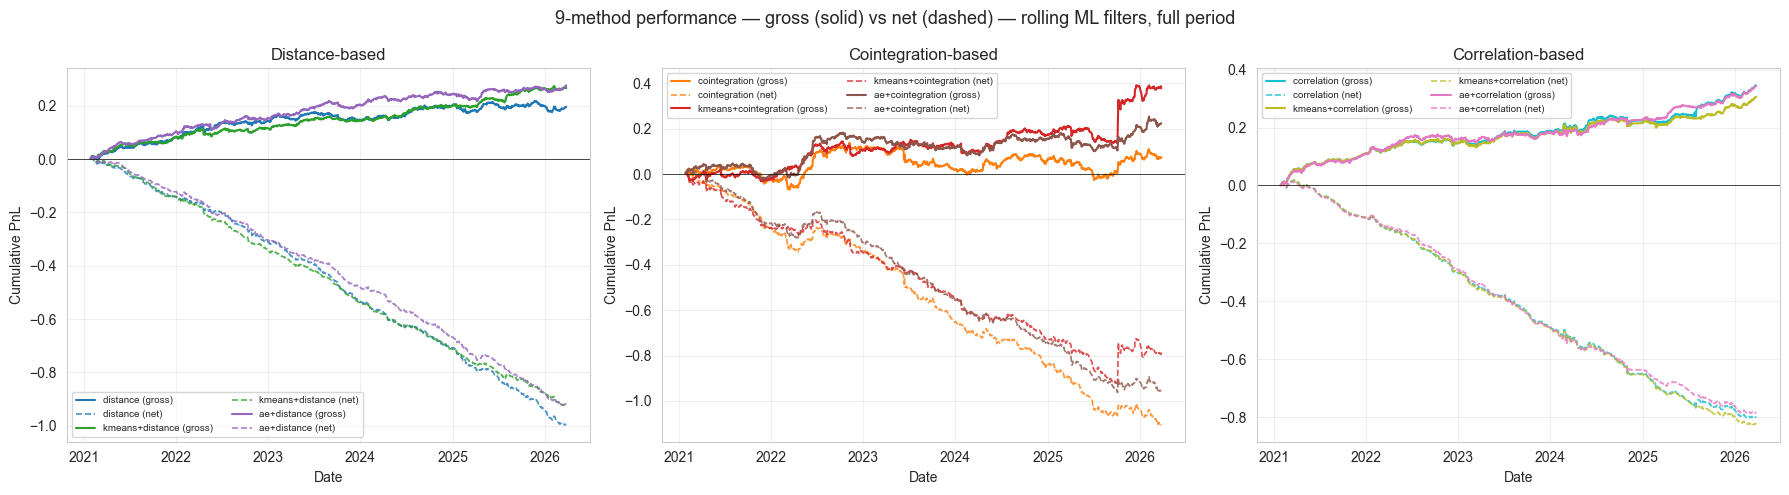

In [45]:
# Bloc 4.8 — Signature equity curves: gross (solid) + net (dashed), 3-panel

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

selection_groups = {
    "Distance-based":       ["distance", "kmeans+distance", "ae+distance"],
    "Cointegration-based":  ["cointegration", "kmeans+cointegration", "ae+cointegration"],
    "Correlation-based":    ["correlation", "kmeans+correlation", "ae+correlation"],
}

colors = {
    "distance": "C0", "kmeans+distance": "C2", "ae+distance": "C4",
    "cointegration": "C1", "kmeans+cointegration": "C3", "ae+cointegration": "C5",
    "correlation": "C9", "kmeans+correlation": "C8", "ae+correlation": "C6",
}

for ax, (group_name, methods) in zip(axes, selection_groups.items()):
    for m in methods:
        color = colors.get(m, "gray")
        
        # Gross: solid line
        pnl_g = result_full["gross"][m]
        daily_g = pnl_g.groupby(pnl_g.index.date).sum()
        daily_g.index = pd.to_datetime(daily_g.index)
        cum_g = daily_g.cumsum()
        ax.plot(cum_g.index, cum_g.values, label=f"{m} (gross)",
                color=color, lw=1.5, ls="-")
        
        # Net: dashed line, same color
        pnl_n = result_full["net"][m]
        daily_n = pnl_n.groupby(pnl_n.index.date).sum()
        daily_n.index = pd.to_datetime(daily_n.index)
        cum_n = daily_n.cumsum()
        ax.plot(cum_n.index, cum_n.values, label=f"{m} (net)",
                color=color, lw=1.2, ls="--", alpha=0.8)
    
    ax.set_title(group_name)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative PnL")
    ax.legend(loc="best", fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    ax.axhline(0, color="black", lw=0.5)

fig.suptitle("9-method performance — gross (solid) vs net (dashed) — rolling ML filters, full period",
             fontsize=13)
plt.tight_layout()
plt.savefig("fig_signature.png", dpi=100, bbox_inches="tight")
plt.show()


K-means: 39 tickers common to all 29 refits

Adjusted Rand Index between consecutive K-means refits:
  Window  30: ARI = 1.000
  Window  40: ARI = 1.000
  Window  50: ARI = 1.000
  Window  60: ARI = 1.000
  Window  70: ARI = 1.000
  ... (28 refits total)

AE: 39 tickers common to all 29 refits

Mean Jaccard between consecutive AE refits:
  Window  30: Jaccard = 0.465
  Window  40: Jaccard = 0.563
  Window  50: Jaccard = 0.648
  Window  60: Jaccard = 0.538
  Window  70: Jaccard = 0.553
  ... (28 refits total)


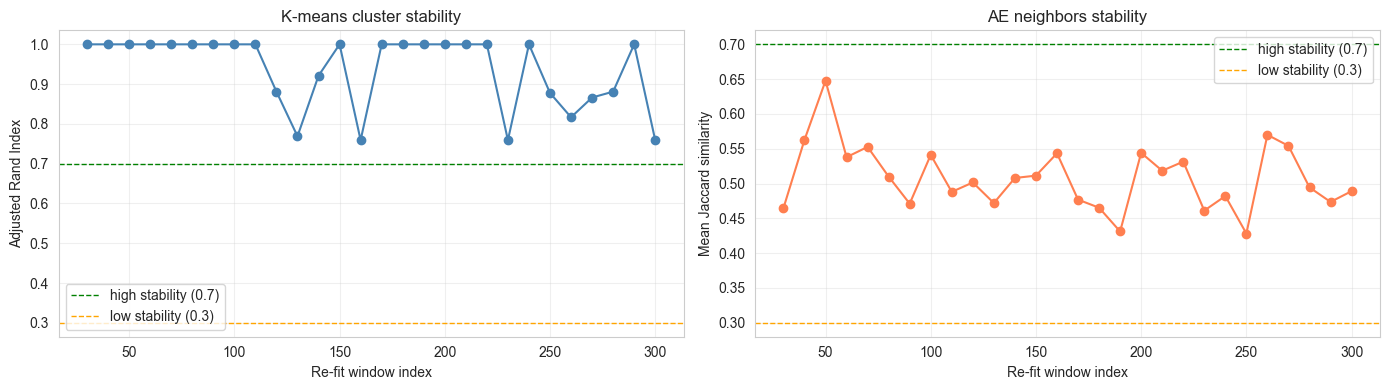


Mean ARI: 0.939
Mean Jaccard: 0.508


In [46]:
# Bloc 4.9 — Stability analysis of rolling filters (ARI + Jaccard)

from sklearn.metrics import adjusted_rand_score

# K-means stability
refit_windows_km = sorted([wi for wi, v in cluster_history.items() if v is not None])
common_tickers_km = sorted(
    set.intersection(*[set(cluster_history[wi].keys()) for wi in refit_windows_km])
)
print(f"K-means: {len(common_tickers_km)} tickers common to all {len(refit_windows_km)} refits")

ari_scores = []
for i in range(1, len(refit_windows_km)):
    labels_prev = [cluster_history[refit_windows_km[i-1]][t] for t in common_tickers_km]
    labels_curr = [cluster_history[refit_windows_km[i]][t]   for t in common_tickers_km]
    ari = adjusted_rand_score(labels_prev, labels_curr)
    ari_scores.append((refit_windows_km[i], ari))

print("\nAdjusted Rand Index between consecutive K-means refits:")
for wi, ari in ari_scores[:5]:
    print(f"  Window {wi:3d}: ARI = {ari:.3f}")
print(f"  ... ({len(ari_scores)} refits total)")


# AE neighbor stability
refit_windows_ae = sorted([wi for wi, v in neighbor_history.items() if v is not None])
common_tickers_ae = sorted(
    set.intersection(*[set(neighbor_history[wi].keys()) for wi in refit_windows_ae])
)
print(f"\nAE: {len(common_tickers_ae)} tickers common to all {len(refit_windows_ae)} refits")

def mean_jaccard(nn_prev, nn_curr, tickers):
    jaccs = []
    for t in tickers:
        a = nn_prev[t]; b = nn_curr[t]
        jac = len(a & b) / len(a | b) if len(a | b) > 0 else 1.0
        jaccs.append(jac)
    return np.mean(jaccs) if jaccs else np.nan


jac_scores = []
for i in range(1, len(refit_windows_ae)):
    jac = mean_jaccard(
        neighbor_history[refit_windows_ae[i-1]],
        neighbor_history[refit_windows_ae[i]],
        common_tickers_ae,
    )
    jac_scores.append((refit_windows_ae[i], jac))

print("\nMean Jaccard between consecutive AE refits:")
for wi, jac in jac_scores[:5]:
    print(f"  Window {wi:3d}: Jaccard = {jac:.3f}")
print(f"  ... ({len(jac_scores)} refits total)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ari_w = [x[0] for x in ari_scores]; ari_v = [x[1] for x in ari_scores]
axes[0].plot(ari_w, ari_v, "-o", color="steelblue")
axes[0].axhline(0.7, color="green", ls="--", lw=1, label="high stability (0.7)")
axes[0].axhline(0.3, color="orange", ls="--", lw=1, label="low stability (0.3)")
axes[0].set_xlabel("Re-fit window index")
axes[0].set_ylabel("Adjusted Rand Index")
axes[0].set_title("K-means cluster stability")
axes[0].legend(); axes[0].grid(alpha=0.3)

jac_w = [x[0] for x in jac_scores]; jac_v = [x[1] for x in jac_scores]
axes[1].plot(jac_w, jac_v, "-o", color="coral")
axes[1].axhline(0.7, color="green", ls="--", lw=1, label="high stability (0.7)")
axes[1].axhline(0.3, color="orange", ls="--", lw=1, label="low stability (0.3)")
axes[1].set_xlabel("Re-fit window index")
axes[1].set_ylabel("Mean Jaccard similarity")
axes[1].set_title("AE neighbors stability")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_stability.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\nMean ARI: {np.mean(ari_v):.3f}")
print(f"Mean Jaccard: {np.mean(jac_v):.3f}")


## Step 5 — Robustness: threshold sensitivity

The post-cost diagnostic (Bloc 2.4bis / 4.7bis) shows that the gross return per 
round-trip is marginal relative to transaction costs. Before concluding, we test 
whether a **stricter entry threshold** (k = 3.0, 3.5) restores profitability by 
triggering trades only on larger divergences.

**Rationale**: higher k ⇒ fewer but more selective trades ⇒ higher gross per 
round-trip, potentially offsetting fixed transaction costs (Stübinger & Bredthauer 
2017, Table 4 tests k ∈ {1, 1.5, 2, 2.5, 3}).

We replay the full 9-method backtest for k ∈ {2.5, 3.0, 3.5} and compare net 
Sharpe, total PnL, and gross/cost per round-trip across the three settings.

In [47]:
# Bloc 5.1 — Backtest 9 methods for k in {2.5, 3.0, 3.5}

def run_backtest_with_k(windows_subset, offset, label, k_threshold):
    """Same as run_backtest_full but with a parameterized k threshold."""
    pnl_gross = {m: [] for m in method_configs}
    pnl_net = {m: [] for m in method_configs}
    pairs_rows = []
    skipped = 0
    traded = 0
    t0 = time.time()
    
    for i, (formation_days, trading_days) in enumerate(windows_subset):
        global_wi = offset + i
        if i % 20 == 0:
            print(f"  [{label} k={k_threshold}] Window {i}/{len(windows_subset)}  ({time.time()-t0:.0f}s)")
        if global_wi < WARMUP_WINDOWS:
            skipped += 1
            continue
        if get_cluster_for_window(global_wi) is None or get_neighbors_for_window(global_wi) is None:
            skipped += 1
            continue
        traded += 1
        
        for m_name, select_fn in method_configs.items():
            pair_list = select_fn(formation_days, global_wi)
            pair_g, pair_n = [], []
            for (a, b, score) in pair_list:
                alpha, beta = compute_hedge_ratio(formation_days, a, b, close_m1, day_flags)
                spread, z, position = generate_signals(
                    formation_days, trading_days, a, b, beta, close_m1, k=k_threshold
                )
                pnl_beta = beta if "cointegration" in m_name else None
                pg, pn = compute_pair_pnl_net(position, a, b, close_m1, trading_days, beta=pnl_beta)
                pair_g.append(pg)
                pair_n.append(pn)
                n_halfturns = int((position.diff().fillna(0).abs() > 0).sum())
                pairs_rows.append({
                    "k": k_threshold, "window_idx": global_wi, "method": m_name,
                    "ticker_a": a, "ticker_b": b,
                    "pair_gross_pnl": pg.sum(), "pair_net_pnl": pn.sum(),
                    "pair_n_halfturns": n_halfturns,
                })
            if pair_g:
                pnl_gross[m_name].append(pd.concat(pair_g, axis=1).mean(axis=1))
                pnl_net[m_name].append(pd.concat(pair_n, axis=1).mean(axis=1))
    
    print(f"  [{label} k={k_threshold}] traded {traded}, skipped {skipped} (warmup)")
    return {
        "gross": {m: pd.concat(v).sort_index() if v else pd.Series(dtype=float)
                  for m, v in pnl_gross.items()},
        "net":   {m: pd.concat(v).sort_index() if v else pd.Series(dtype=float)
                  for m, v in pnl_net.items()},
        "pairs_log": pd.DataFrame(pairs_rows),
    }


k_grid = [2.5, 3.0, 3.5]
k_results = {}
for k in k_grid:
    print(f"\n=== k = {k} ===")
    k_results[k] = run_backtest_with_k(windows_all, offset=0, label="k_sens", k_threshold=k)



=== k = 2.5 ===
  [k_sens k=2.5] Window 0/309  (0s)
  [k_sens k=2.5] Window 20/309  (0s)
  [k_sens k=2.5] Window 40/309  (0s)
  [k_sens k=2.5] Window 60/309  (61s)
  [k_sens k=2.5] Window 80/309  (186s)
  [k_sens k=2.5] Window 100/309  (310s)
  [k_sens k=2.5] Window 120/309  (437s)
  [k_sens k=2.5] Window 140/309  (568s)
  [k_sens k=2.5] Window 160/309  (707s)
  [k_sens k=2.5] Window 180/309  (922s)
  [k_sens k=2.5] Window 200/309  (1159s)
  [k_sens k=2.5] Window 220/309  (1379s)
  [k_sens k=2.5] Window 240/309  (1600s)
  [k_sens k=2.5] Window 260/309  (1792s)
  [k_sens k=2.5] Window 280/309  (1931s)
  [k_sens k=2.5] Window 300/309  (2063s)
  [k_sens k=2.5] traded 259, skipped 50 (warmup)

=== k = 3.0 ===
  [k_sens k=3.0] Window 0/309  (0s)
  [k_sens k=3.0] Window 20/309  (0s)
  [k_sens k=3.0] Window 40/309  (0s)
  [k_sens k=3.0] Window 60/309  (69s)
  [k_sens k=3.0] Window 80/309  (210s)
  [k_sens k=3.0] Window 100/309  (346s)
  [k_sens k=3.0] Window 120/309  (508s)
  [k_sens k=3.0] 

In [48]:
# Bloc 5.2 — Summary tables: gross + net performance across k thresholds

def _sum_metrics(pnl_series):
    if len(pnl_series) == 0:
        return {"total_pnl": 0.0, "sharpe": np.nan, "sortino": np.nan, "max_dd": 0.0}
    daily = pnl_series.groupby(pnl_series.index.date).sum()
    if len(daily) < 10:
        return {"total_pnl": daily.sum(), "sharpe": np.nan, "sortino": np.nan, "max_dd": 0.0}
    mean_d, std_d = daily.mean(), daily.std()
    sharpe = mean_d / std_d * np.sqrt(252) if std_d > 0 else np.nan
    neg = daily[daily < 0]
    sortino = mean_d / neg.std() * np.sqrt(252) if len(neg) > 1 else np.nan
    cum = daily.cumsum()
    dd = (cum - cum.cummax()).min()
    return {"total_pnl": daily.sum(), "sharpe": sharpe, "sortino": sortino, "max_dd": dd}


rows = []
for k, res in k_results.items():
    for m in res["net"]:
        mt_g = _sum_metrics(res["gross"][m])
        mt_n = _sum_metrics(res["net"][m])
        log = res["pairs_log"]
        log_m = log[log["method"] == m]
        n_rt = log_m["pair_n_halfturns"].sum() / 2 if len(log_m) else 0
        total_gross = log_m["pair_gross_pnl"].sum()
        total_cost = (log_m["pair_gross_pnl"] - log_m["pair_net_pnl"]).sum()
        gross_per_rt = (total_gross / n_rt * 10000) if n_rt > 0 else np.nan
        cost_per_rt  = (total_cost / n_rt * 10000) if n_rt > 0 else np.nan
        rows.append({
            "k": k, "method": m,
            # Gross side
            "total_gross_pnl": mt_g["total_pnl"],
            "sharpe_gross":   mt_g["sharpe"],
            "sortino_gross":  mt_g["sortino"],
            "max_dd_gross":   mt_g["max_dd"],
            # Net side
            "total_net_pnl":  mt_n["total_pnl"],
            "sharpe_net":     mt_n["sharpe"],
            "sortino_net":    mt_n["sortino"],
            "max_dd_net":     mt_n["max_dd"],
            # Round-trip stats
            "n_round_trips":   n_rt,
            "gross_per_rt_bps": gross_per_rt,
            "cost_per_rt_bps": cost_per_rt,
            "net_per_rt_bps":  gross_per_rt - cost_per_rt if n_rt > 0 else np.nan,
        })

k_summary = pd.DataFrame(rows)

method_order = [
    "distance", "kmeans+distance", "ae+distance",
    "cointegration", "kmeans+cointegration", "ae+cointegration",
    "correlation", "kmeans+correlation", "ae+correlation",
]

# Pivots: method × k, for both gross and net
pivot_sharpe_gross = k_summary.pivot(index="method", columns="k", values="sharpe_gross").reindex(method_order).round(3)
pivot_sharpe_net   = k_summary.pivot(index="method", columns="k", values="sharpe_net").reindex(method_order).round(3)
pivot_pnl_gross    = k_summary.pivot(index="method", columns="k", values="total_gross_pnl").reindex(method_order).round(4)
pivot_pnl_net      = k_summary.pivot(index="method", columns="k", values="total_net_pnl").reindex(method_order).round(4)
pivot_gross_rt     = k_summary.pivot(index="method", columns="k", values="gross_per_rt_bps").reindex(method_order).round(2)
pivot_nrt          = k_summary.pivot(index="method", columns="k", values="n_round_trips").reindex(method_order).round(0)

print("=" * 90)
print("SHARPE GROSS by method × k")
print("=" * 90)
print(pivot_sharpe_gross.to_string())

print("\n" + "=" * 90)
print("SHARPE NET by method × k")
print("=" * 90)
print(pivot_sharpe_net.to_string())

print("\n" + "=" * 90)
print("TOTAL GROSS PNL (cumulative, % over full period) by method × k")
print("=" * 90)
print((pivot_pnl_gross * 100).to_string())

print("\n" + "=" * 90)
print("TOTAL NET PNL (cumulative, % over full period) by method × k")
print("=" * 90)
print((pivot_pnl_net * 100).to_string())

print("\n" + "=" * 90)
print("GROSS PER ROUND-TRIP (bps) by method × k")
print("=" * 90)
print(pivot_gross_rt.to_string())

print("\n" + "=" * 90)
print("NUMBER OF ROUND-TRIPS by method × k")
print("=" * 90)
print(pivot_nrt.to_string())


SHARPE GROSS by method × k
k                       2.5    3.0    3.5
method                                   
distance              1.145  0.850  0.614
kmeans+distance       1.736  1.583  1.386
ae+distance           1.777  1.541  1.219
cointegration         0.189 -0.012 -0.047
kmeans+cointegration  0.691  0.670  0.548
ae+cointegration      0.630  0.523  0.356
correlation           1.787  1.629  1.333
kmeans+correlation    1.658  1.592  1.157
ae+correlation        1.947  1.782  1.446

SHARPE NET by method × k
k                       2.5    3.0    3.5
method                                   
distance             -6.005 -4.856 -4.054
kmeans+distance      -6.246 -4.742 -3.812
ae+distance          -6.135 -4.694 -3.722
cointegration        -2.871 -2.518 -2.051
kmeans+cointegration -1.475 -1.018 -1.145
ae+cointegration     -2.741 -2.202 -2.140
correlation          -4.298 -3.223 -2.722
kmeans+correlation   -4.636 -3.393 -2.976
ae+correlation       -4.617 -3.646 -2.913

TOTAL GROSS PNL (cumul

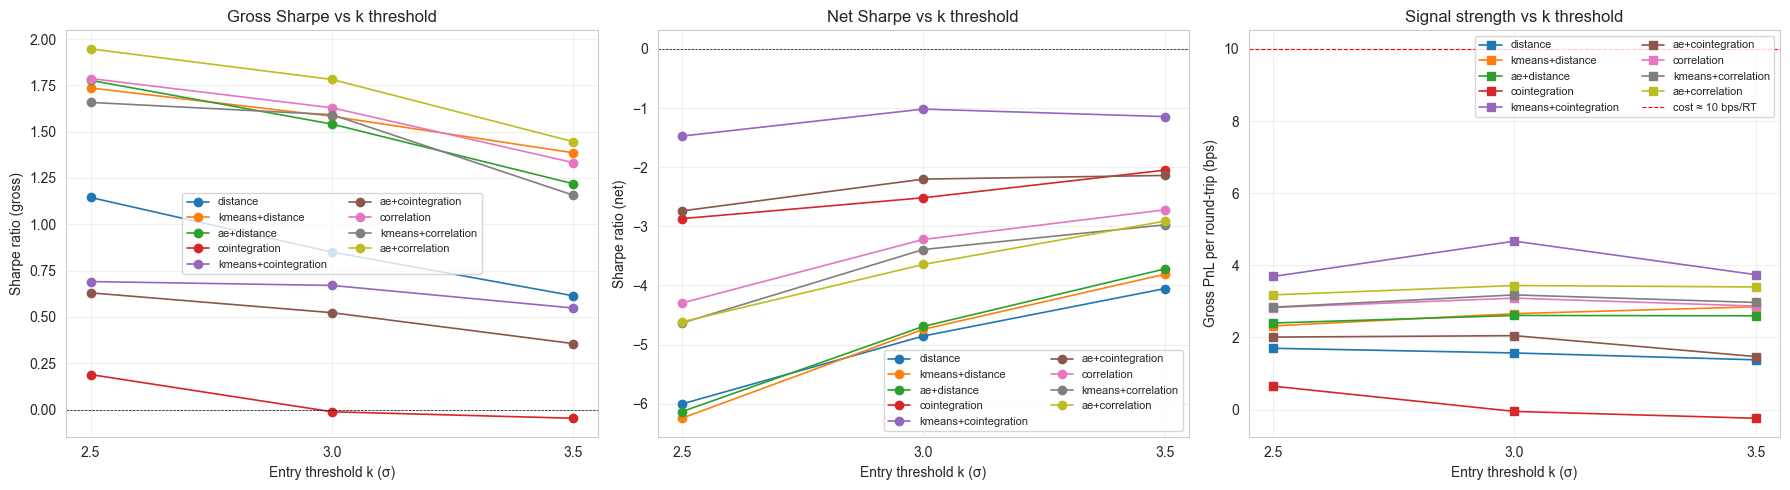


=== Best k per method (by Sharpe, gross & net) ===
                      k_gross  sharpe_gross_gross  total_gross_pnl_gross  k_net  sharpe_net_net  total_net_pnl_net
method                                                                                                            
distance                  2.5               1.145                  0.197    3.5          -4.054             -0.539
kmeans+distance           2.5               1.736                  0.266    3.5          -3.812             -0.456
ae+distance               2.5               1.777                  0.276    3.5          -3.722             -0.468
cointegration             2.5               0.189                  0.074    3.5          -2.051             -0.643
kmeans+cointegration      2.5               0.691                  0.378    3.0          -1.018             -0.526
ae+cointegration          2.5               0.630                  0.224    3.5          -2.140             -0.542
correlation               2.

In [49]:
# Bloc 5.3 — Visualization: gross + net Sharpe and gross/RT across k

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Sharpe GROSS vs k
ax = axes[0]
for m in method_order:
    ax.plot(k_grid, pivot_sharpe_gross.loc[m].values, marker="o", label=m, lw=1.2)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("Entry threshold k (σ)")
ax.set_ylabel("Sharpe ratio (gross)")
ax.set_title("Gross Sharpe vs k threshold")
ax.set_xticks(k_grid)
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# Middle: Sharpe NET vs k
ax = axes[1]
for m in method_order:
    ax.plot(k_grid, pivot_sharpe_net.loc[m].values, marker="o", label=m, lw=1.2)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("Entry threshold k (σ)")
ax.set_ylabel("Sharpe ratio (net)")
ax.set_title("Net Sharpe vs k threshold")
ax.set_xticks(k_grid)
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# Right: gross/RT vs k with cost line
ax = axes[2]
for m in method_order:
    ax.plot(k_grid, pivot_gross_rt.loc[m].values, marker="s", label=m, lw=1.2)
ax.axhline(10, color="r", lw=0.8, ls="--", label="cost ≈ 10 bps/RT")
ax.set_xlabel("Entry threshold k (σ)")
ax.set_ylabel("Gross PnL per round-trip (bps)")
ax.set_title("Signal strength vs k threshold")
ax.set_xticks(k_grid)
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify best k per method (gross and net)
best_k_gross = k_summary.loc[k_summary.groupby("method")["sharpe_gross"].idxmax(), 
                             ["method", "k", "sharpe_gross", "total_gross_pnl"]]
best_k_gross = best_k_gross.set_index("method").reindex(method_order).add_suffix("_gross")

best_k_net = k_summary.loc[k_summary.groupby("method")["sharpe_net"].idxmax(), 
                           ["method", "k", "sharpe_net", "total_net_pnl"]]
best_k_net = best_k_net.set_index("method").reindex(method_order).add_suffix("_net")

best_k = best_k_gross.join(best_k_net)
print("\n=== Best k per method (by Sharpe, gross & net) ===")
print(best_k.round(3).to_string())

# Synthesis
best_gross = k_summary.loc[k_summary["sharpe_gross"].idxmax()]
best_net   = k_summary.loc[k_summary["sharpe_net"].idxmax()]
print(f"\n>>> Best GROSS config: method={best_gross['method']}, k={best_gross['k']}, "
      f"Sharpe_gross={best_gross['sharpe_gross']:.3f}, total_gross={best_gross['total_gross_pnl']*100:.2f}%")
print(f">>> Best NET   config: method={best_net['method']}, k={best_net['k']}, "
      f"Sharpe_net={best_net['sharpe_net']:.3f}, total_net={best_net['total_net_pnl']*100:.2f}%")


## Step 6 — Synthesis and master comparison

Consolidation of all results into the main performance table, a Sharpe 
comparison chart, and a final ranking by test period Sharpe.

Note: detailed interpretation, discussion of which method is most 
appropriate, and limitations are provided in the accompanying research 
report.


In [50]:
# Bloc 6.1 — Master summary table (gross + net + k sensitivity)

master_rows = []
for m in method_configs:
    mg = summary_gross.loc[m] if m in summary_gross.index else None
    mn = summary_net.loc[m]   if m in summary_net.index   else None
    
    # Best k from Step 5 k-sensitivity analysis (net-based)
    best_k_row_n = k_summary[k_summary["method"] == m].sort_values("sharpe_net", ascending=False).head(1)
    best_k_n = best_k_row_n["k"].iloc[0] if len(best_k_row_n) else np.nan
    best_k_n_sharpe = best_k_row_n["sharpe_net"].iloc[0] if len(best_k_row_n) else np.nan
    
    # Best k gross-based
    best_k_row_g = k_summary[k_summary["method"] == m].sort_values("sharpe_gross", ascending=False).head(1)
    best_k_g = best_k_row_g["k"].iloc[0] if len(best_k_row_g) else np.nan
    best_k_g_sharpe = best_k_row_g["sharpe_gross"].iloc[0] if len(best_k_row_g) else np.nan
    
    row = {"method": m}
    if mg is not None:
        row["sharpe_gross"]    = mg["sharpe"]
        row["total_pnl_gross"] = mg["total_pnl"]
        row["max_dd_gross"]    = mg["max_dd"]
    if mn is not None:
        row["sharpe_net"]      = mn["sharpe"]
        row["total_pnl_net"]   = mn["total_pnl"]
        row["max_dd_net"]      = mn["max_dd"]
        row["calmar_net"]      = mn["calmar"]
        row["win_rate_net"]    = mn["win_rate"]
    row["best_k_gross"]        = best_k_g
    row["best_k_gross_sharpe"] = best_k_g_sharpe
    row["best_k_net"]          = best_k_n
    row["best_k_net_sharpe"]   = best_k_n_sharpe
    master_rows.append(row)

master_df = pd.DataFrame(master_rows).set_index("method").round(3)

# Sort by net Sharpe
master_df = master_df.sort_values("sharpe_net", ascending=False)

# Reorder columns: gross first, then net, then k-sensitivity
col_order = [
    "sharpe_gross", "sharpe_net",
    "total_pnl_gross", "total_pnl_net",
    "max_dd_gross", "max_dd_net",
    "calmar_net", "win_rate_net",
    "best_k_gross", "best_k_gross_sharpe",
    "best_k_net",   "best_k_net_sharpe",
]
master_df = master_df[[c for c in col_order if c in master_df.columns]]

print("=" * 130)
print("MASTER COMPARISON: 9 methods × (gross, net, best k sensitivity)")
print("=" * 130)
print(master_df.to_string())

master_df.to_csv("master_summary.csv")
print("\nSaved to master_summary.csv")


MASTER COMPARISON: 9 methods × (gross, net, best k sensitivity)
                      sharpe_gross  sharpe_net  total_pnl_gross  total_pnl_net  max_dd_gross  max_dd_net  calmar_net  win_rate_net  best_k_gross  best_k_gross_sharpe  best_k_net  best_k_net_sharpe
method                                                                                                                                                                                              
kmeans+cointegration         0.691      -1.475            0.378         -0.799        -0.075      -0.937      -0.166         0.424           2.5                0.691         3.0             -1.018
ae+cointegration             0.630      -2.741            0.224         -0.954        -0.102      -0.976      -0.190         0.422           2.5                0.630         3.5             -2.140
cointegration                0.189      -2.871            0.074         -1.103        -0.164      -1.120      -0.192         0.414           2.5    

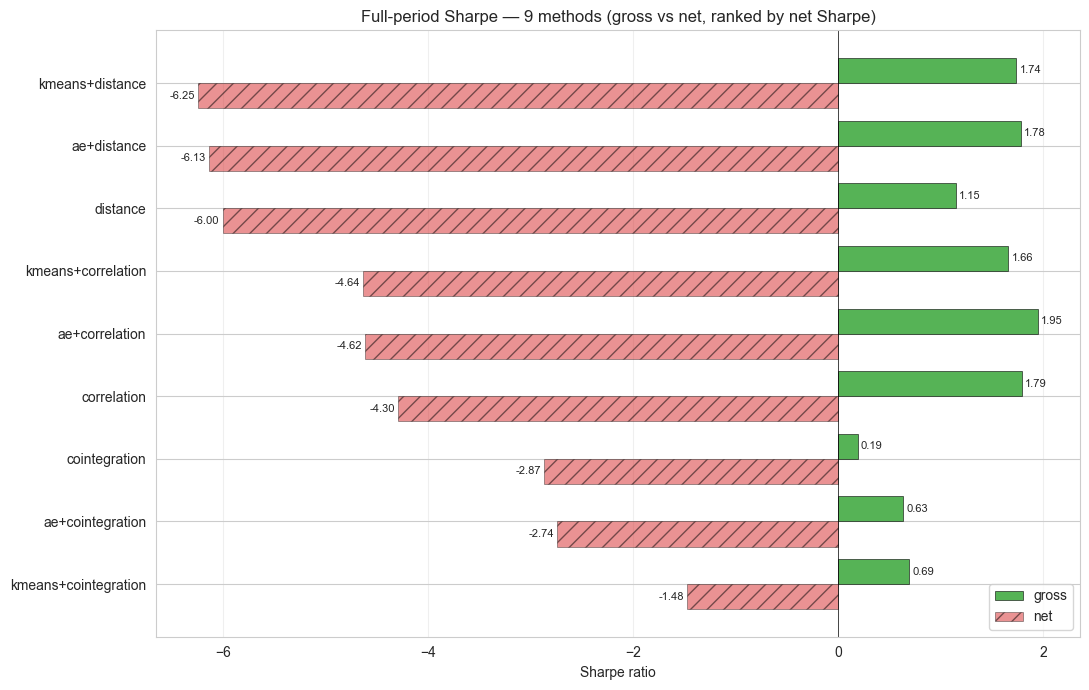

In [52]:
# Bloc 6.2 — Sharpe ratio bar chart (gross + net)

methods_ord = master_df.index.tolist()
y_pos = np.arange(len(methods_ord))
bar_h = 0.4

fig, ax = plt.subplots(figsize=(11, 7))

sharpe_g = master_df["sharpe_gross"].values
sharpe_n = master_df["sharpe_net"].values

# Gross bars (above), net bars (below), grouped per method
ax.barh(y_pos + bar_h/2, sharpe_g, height=bar_h, alpha=0.8,
        color=["tab:green" if s > 0 else "tab:red" for s in sharpe_g],
        edgecolor="black", lw=0.5, label="gross")
ax.barh(y_pos - bar_h/2, sharpe_n, height=bar_h, alpha=0.5,
        color=["tab:green" if s > 0 else "tab:red" for s in sharpe_n],
        edgecolor="black", lw=0.5, hatch="//", label="net")

ax.set_yticks(y_pos)
ax.set_yticklabels(methods_ord)
ax.set_xlabel("Sharpe ratio")
ax.set_title("Full-period Sharpe — 9 methods (gross vs net, ranked by net Sharpe)")
ax.axvline(0, color="black", lw=0.5)
ax.grid(alpha=0.3, axis="x")
ax.legend(loc="lower right")

# Annotate
for i, (g, n) in enumerate(zip(sharpe_g, sharpe_n)):
    ax.text(g + (0.03 if g >= 0 else -0.03), i + bar_h/2, f"{g:.2f}",
            va="center", ha="left" if g >= 0 else "right", fontsize=8)
    ax.text(n + (0.03 if n >= 0 else -0.03), i - bar_h/2, f"{n:.2f}",
            va="center", ha="left" if n >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig("fig_master_sharpe.png", dpi=100, bbox_inches="tight")
plt.show()


In [53]:
# Bloc 6.3 — Final synthesis

print("=" * 80)
print("SYNTHESIS OF KEY FINDINGS (full period, Stübinger β-OLS convention)")
print("=" * 80)

# Best method by GROSS Sharpe (best signal, before costs)
best_sh_g = master_df["sharpe_gross"].idxmax()
print(f"\n★ Best method by GROSS Sharpe: {best_sh_g}")
print(f"  Sharpe gross : {master_df.loc[best_sh_g, 'sharpe_gross']:.3f}")
print(f"  Sharpe net   : {master_df.loc[best_sh_g, 'sharpe_net']:.3f}")
print(f"  Total gross  : {master_df.loc[best_sh_g, 'total_pnl_gross']*100:+.2f}%")
print(f"  Total net    : {master_df.loc[best_sh_g, 'total_pnl_net']*100:+.2f}%")

# Best method by NET Sharpe (best after-costs performance)
best_sh_n = master_df["sharpe_net"].idxmax()
print(f"\n★ Best method by NET Sharpe: {best_sh_n}")
print(f"  Sharpe gross : {master_df.loc[best_sh_n, 'sharpe_gross']:.3f}")
print(f"  Sharpe net   : {master_df.loc[best_sh_n, 'sharpe_net']:.3f}")
print(f"  Total gross  : {master_df.loc[best_sh_n, 'total_pnl_gross']*100:+.2f}%")
print(f"  Total net    : {master_df.loc[best_sh_n, 'total_pnl_net']*100:+.2f}%")

# Cost drag per method
print("\n★ Cost drag (gross_pnl − net_pnl), sorted by magnitude:")
cost_drag = (master_df["total_pnl_gross"] - master_df["total_pnl_net"]).sort_values(ascending=False)
for m, d in cost_drag.items():
    print(f"  {m:25s}: {d*100:+.2f}%")

# Methods with positive NET Sharpe
print("\n★ Methods with positive NET Sharpe:")
positive = master_df[master_df["sharpe_net"] > 0]
if len(positive) > 0:
    for m, r in positive.iterrows():
        print(f"  {m:25s}: Sh_net={r['sharpe_net']:.3f}, Sh_gross={r['sharpe_gross']:.3f}, Net PnL={r['total_pnl_net']*100:+.2f}%")
else:
    print("  None — consistent with Landgraf (2016) secular decline finding.")

# Cointegration diagnosis (as before, but gross + net)
print("\n★ Cointegration-based methods (per-family check):")
for m in ["cointegration", "kmeans+cointegration", "ae+cointegration"]:
    if m in master_df.index:
        r = master_df.loc[m]
        print(f"  {m:25s}: Sh_gross={r['sharpe_gross']:.3f}, Sh_net={r['sharpe_net']:.3f}, "
              f"Gross PnL={r['total_pnl_gross']*100:+.2f}%, Net PnL={r['total_pnl_net']*100:+.2f}%")

# k-sensitivity winners
print("\n★ Methods where higher k improves NET Sharpe:")
for m in master_df.index:
    base_row = k_summary[(k_summary["method"] == m) & (k_summary["k"] == 2.5)]
    if len(base_row) == 0:
        continue
    base_sharpe = base_row["sharpe_net"].iloc[0]
    best_k_for_m = master_df.loc[m, "best_k_net"]
    best_sharpe_for_m = master_df.loc[m, "best_k_net_sharpe"]
    if best_k_for_m > 2.5 and best_sharpe_for_m > base_sharpe:
        delta = best_sharpe_for_m - base_sharpe
        print(f"  {m:25s}: k=2.5 Sh={base_sharpe:.3f} → k={best_k_for_m} Sh={best_sharpe_for_m:.3f}  (Δ={delta:+.3f})")


SYNTHESIS OF KEY FINDINGS (full period, Stübinger β-OLS convention)

★ Best method by GROSS Sharpe: ae+correlation
  Sharpe gross : 1.947
  Sharpe net   : -4.617
  Total gross  : +34.30%
  Total net    : -78.60%

★ Best method by NET Sharpe: kmeans+cointegration
  Sharpe gross : 0.691
  Sharpe net   : -1.475
  Total gross  : +37.80%
  Total net    : -79.90%

★ Cost drag (gross_pnl − net_pnl), sorted by magnitude:
  ae+distance              : +119.60%
  kmeans+distance          : +119.60%
  distance                 : +119.30%
  ae+cointegration         : +117.80%
  kmeans+cointegration     : +117.70%
  cointegration            : +117.70%
  correlation              : +114.70%
  kmeans+correlation       : +113.00%
  ae+correlation           : +112.90%

★ Methods with positive NET Sharpe:
  None — consistent with Landgraf (2016) secular decline finding.

★ Cointegration-based methods (per-family check):
  cointegration            : Sh_gross=0.189, Sh_net=-2.871, Gross PnL=+7.40%, Net PnL=-

In [54]:
# Bloc 6.4 — Sub-period stability analysis (4 segments)

def compute_subperiod_sharpes(pnl_m1, n_periods=4):
    """Split PnL series into n contiguous sub-periods and compute Sharpe for each.
    Returns dict {period_label: {start, end, sharpe, total_pnl, n_days}}."""
    daily = pnl_m1.groupby(pnl_m1.index.date).sum()
    daily.index = pd.to_datetime(daily.index)
    if len(daily) < n_periods * 20:
        return None
    
    n = len(daily)
    chunk = n // n_periods
    
    results = {}
    for k in range(n_periods):
        start_idx = k * chunk
        end_idx = (k + 1) * chunk if k < n_periods - 1 else n
        sub = daily.iloc[start_idx:end_idx]
        
        mean_d, std_d = sub.mean(), sub.std()
        sharpe = mean_d / std_d * np.sqrt(252) if std_d > 0 else np.nan
        
        results[f"P{k+1}"] = {
            "start": sub.index[0].date(),
            "end":   sub.index[-1].date(),
            "sharpe": sharpe,
            "total_pnl": sub.sum(),
            "n_days": len(sub),
        }
    return results


# Compute sub-period Sharpes for all 9 methods
subperiod_rows = []
for m in method_configs:
    pnl = result_full["net"][m]
    sp = compute_subperiod_sharpes(pnl, n_periods=4)
    if sp is None:
        continue
    row = {"method": m}
    for pk, p_data in sp.items():
        row[f"{pk}_sharpe"] = p_data["sharpe"]
        row[f"{pk}_period"] = f"{p_data['start']}/{p_data['end']}"
    subperiod_rows.append(row)

subperiod_df = pd.DataFrame(subperiod_rows).set_index("method")

# Show periods first
print("=" * 85)
print("SUB-PERIOD BOUNDARIES (from first method)")
print("=" * 85)
first_method_sp = compute_subperiod_sharpes(result_full["net"][list(method_configs)[0]], 4)
for pk, p_data in first_method_sp.items():
    print(f"  {pk}: {p_data['start']} → {p_data['end']}  ({p_data['n_days']} days)")

# Show Sharpe table
sharpe_cols = [c for c in subperiod_df.columns if c.endswith("_sharpe")]
subperiod_sharpes = subperiod_df[sharpe_cols].round(3)
subperiod_sharpes.columns = [c.replace("_sharpe", "") for c in subperiod_sharpes.columns]

# Add full-period Sharpe for reference
subperiod_sharpes["Full"] = master_df["sharpe_net"].reindex(subperiod_sharpes.index)

# Sort by full-period Sharpe
subperiod_sharpes = subperiod_sharpes.sort_values("Full", ascending=False)

print("\n" + "=" * 85)
print("SUB-PERIOD SHARPE RATIOS (9 methods × 4 sub-periods + full)")
print("=" * 85)
print(subperiod_sharpes.to_string())

# Stability metric: std of sub-period Sharpes
p_cols = ["P1", "P2", "P3", "P4"]
subperiod_sharpes["Sh_std"] = subperiod_sharpes[p_cols].std(axis=1).round(3)
subperiod_sharpes["Sh_mean"] = subperiod_sharpes[p_cols].mean(axis=1).round(3)
subperiod_sharpes["Sh_min"] = subperiod_sharpes[p_cols].min(axis=1).round(3)

print("\n" + "=" * 85)
print("STABILITY METRICS across 4 sub-periods:")
print("  Sh_mean = average across 4 periods (should be close to Full)")
print("  Sh_std  = cross-period Sharpe variability (lower = more stable)")
print("  Sh_min  = worst sub-period (signal of tail regime risk)")
print("=" * 85)
print(subperiod_sharpes[["Full", "Sh_mean", "Sh_std", "Sh_min"] + p_cols].to_string())

subperiod_sharpes.to_csv("subperiod_sharpes.csv")


SUB-PERIOD BOUNDARIES (from first method)
  P1: 2021-01-28 → 2022-05-09  (323 days)
  P2: 2022-05-10 → 2023-08-22  (323 days)
  P3: 2023-08-23 → 2024-12-03  (323 days)
  P4: 2024-12-04 → 2026-03-25  (326 days)

SUB-PERIOD SHARPE RATIOS (9 methods × 4 sub-periods + full)
                         P1     P2     P3     P4   Full
method                                                 
kmeans+cointegration -2.931 -2.492 -2.782 -0.431 -1.475
ae+cointegration     -2.939 -2.665 -3.757 -2.137 -2.741
cointegration        -3.443 -2.178 -3.304 -2.812 -2.871
correlation          -4.291 -6.211 -4.049 -3.391 -4.298
ae+correlation       -4.052 -6.259 -4.391 -3.979 -4.617
kmeans+correlation   -4.197 -6.425 -4.064 -4.431 -4.636
distance             -4.578 -6.244 -6.526 -6.714 -6.005
ae+distance          -5.695 -5.702 -6.375 -6.750 -6.135
kmeans+distance      -5.516 -6.478 -7.853 -5.599 -6.246

STABILITY METRICS across 4 sub-periods:
  Sh_mean = average across 4 periods (should be close to Full)
  Sh_std 

Top 5 methods by Sharpe: ['kmeans+cointegration', 'ae+cointegration', 'cointegration', 'correlation', 'ae+correlation']


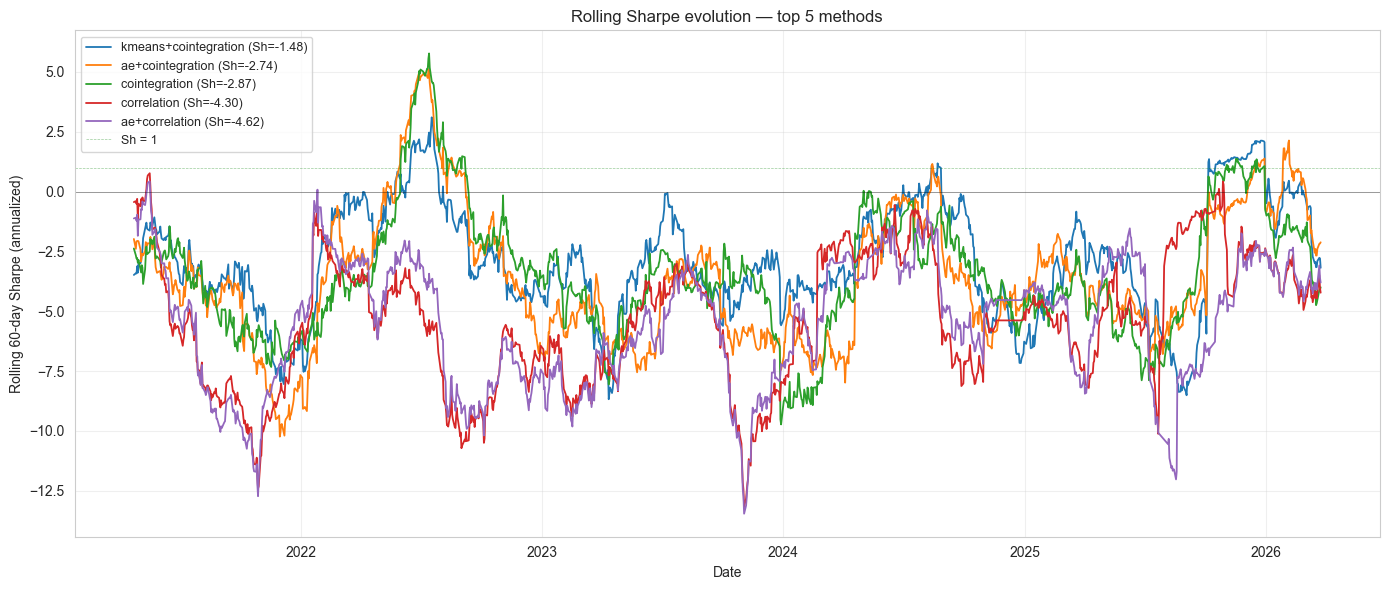


Time-above-threshold statistics (rolling 60d Sharpe):
                      pct_above_0  pct_above_1  mean_rolling  min_rolling  max_rolling
method                                                                                
kmeans+cointegration        11.25         6.96         -2.86        -8.67         3.11
ae+cointegration            10.60         5.83         -3.60       -10.24         5.11
cointegration               10.36         6.31         -3.42        -9.73         5.78
correlation                  0.67         0.00         -5.39       -13.16         0.77
ae+correlation               0.34         0.00         -5.53       -13.46         0.43


In [55]:
# Bloc 6.5 — Rolling Sharpe (60-day window, top 5 methods)

def rolling_sharpe(pnl_m1, window_days=60):
    """Compute a rolling Sharpe on daily PnL."""
    daily = pnl_m1.groupby(pnl_m1.index.date).sum()
    daily.index = pd.to_datetime(daily.index)
    mu = daily.rolling(window_days).mean()
    sd = daily.rolling(window_days).std()
    return (mu / sd * np.sqrt(252)).dropna()


# Top 5 methods by Sharpe
top5 = master_df.sort_values("sharpe_net", ascending=False).head(5).index.tolist()
print(f"Top 5 methods by Sharpe: {top5}")

fig, ax = plt.subplots(figsize=(14, 6))

for m in top5:
    pnl = result_full["net"][m]
    rs = rolling_sharpe(pnl, window_days=60)
    ax.plot(rs.index, rs.values, label=f"{m} (Sh={master_df.loc[m, 'sharpe_net']:.2f})", lw=1.3)

ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.axhline(1, color="g", lw=0.5, ls="--", alpha=0.4, label="Sh = 1")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling 60-day Sharpe (annualized)")
ax.set_title("Rolling Sharpe evolution — top 5 methods")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_rolling_sharpe.png", dpi=100, bbox_inches="tight")
plt.show()

# Summary: time spent above 0 and above 1
print("\n" + "=" * 70)
print("Time-above-threshold statistics (rolling 60d Sharpe):")
print("=" * 70)
stats_rows = []
for m in top5:
    rs = rolling_sharpe(result_full["net"][m], 60)
    stats_rows.append({
        "method":       m,
        "pct_above_0":  (rs > 0).mean() * 100,
        "pct_above_1":  (rs > 1).mean() * 100,
        "mean_rolling": rs.mean(),
        "min_rolling":  rs.min(),
        "max_rolling":  rs.max(),
    })
stats_df = pd.DataFrame(stats_rows).set_index("method").round(2)
print(stats_df.to_string())


## Step 7 — Fama-French alpha analysis

We apply the Fama-French factor regression to quantify whether our 
strategy's returns come from genuine skill or from passive exposure to 
standard risk factors. We follow Stübinger & Bredthauer (2017) closely
for direct benchmarking.

### Three models

- **FF3**: Mkt-RF, SMB, HML (Fama & French 1996)
- **FF3+MOM**: adds momentum (Gatev et al. 2006)
- **FF5**: FF3 + RMW (profitability) + CMA (investment) (Fama & French 2015)

Standard errors use Newey-West HAC correction with 5 lags to account for
serial correlation.

### Stübinger benchmark (for reference)

For their best strategy (EV on top-20 pairs, 1998-2015, ~4500 obs), 
Stübinger reports: daily α = 16 bps (40% annualized), t = 13.77, R² ≈ 2-5%.


In [56]:
# Bloc 7.1 — Load Fama-French factors

import pandas_datareader.data as web

try:
    ff5_raw = web.DataReader(
        "F-F_Research_Data_5_Factors_2x3_daily",
        "famafrench", start="2020-01-01", end="2026-12-31"
    )[0] / 100  # percent to decimal
    mom_raw = web.DataReader(
        "F-F_Momentum_Factor_daily",
        "famafrench", start="2020-01-01", end="2026-12-31"
    )[0] / 100
    
    ff5 = ff5_raw.rename(columns={"Mkt-RF": "MktRF"})
    mom = mom_raw.rename(columns={"Mom   ": "MOM"})
    mom.columns = ["MOM"]
    
    ff_factors = ff5.join(mom, how="inner")
    ff_factors.index = pd.to_datetime(ff_factors.index)
    
    print(f"Loaded FF factors: {ff_factors.shape}")
    print(f"Period: {ff_factors.index[0].date()} to {ff_factors.index[-1].date()}")
    print(f"Columns: {list(ff_factors.columns)}")
    print(f"\nFirst rows:")
    print(ff_factors.head())
    ff_success = True
except Exception as e:
    print(f"Error loading FF factors: {e}")
    print("Will skip FF analysis")
    ff_success = False


C:\Users\pc\AppData\Local\Temp\ipykernel_17356\1508071841.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5_raw = web.DataReader(
C:\Users\pc\AppData\Local\Temp\ipykernel_17356\1508071841.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom_raw = web.DataReader(


Loaded FF factors: (1547, 7)
Period: 2020-01-02 to 2026-02-27
Columns: ['MktRF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM']

First rows:
             MktRF     SMB     HML     RMW     CMA      RF     MOM
Date                                                              
2020-01-02  0.0086 -0.0097 -0.0034  0.0023 -0.0022  0.0001  0.0082
2020-01-03 -0.0067  0.0029  0.0001 -0.0014 -0.0017  0.0001  0.0001
2020-01-06  0.0036 -0.0022 -0.0055 -0.0016 -0.0031  0.0001 -0.0067
2020-01-07 -0.0019 -0.0004 -0.0026 -0.0013 -0.0031  0.0001  0.0001
2020-01-08  0.0047 -0.0018 -0.0064 -0.0021 -0.0015  0.0001  0.0094


In [57]:
# Bloc 7.2 — Convert PnL to daily returns

def pnl_to_returns(pnl_series):
    """Convert M1 PnL (already in return units) to daily returns."""
    daily_ret = pnl_series.groupby(pnl_series.index.date).sum()
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret


In [58]:
# Bloc 7.3 — FF3, FF3+MOM, FF5 regressions on 9 methods

import statsmodels.api as sm

def ff_regression(returns, factors, model="FF5", label=""):
    """Run a FF regression with Newey-West HAC 5-lag standard errors."""
    merged = pd.concat([returns.rename("ret"), factors], axis=1).dropna()
    if len(merged) < 30:
        return None
    
    Y = merged["ret"] - merged["RF"]
    if model == "FF3":
        X = sm.add_constant(merged[["MktRF", "SMB", "HML"]])
    elif model == "FF3+MOM":
        X = sm.add_constant(merged[["MktRF", "SMB", "HML", "MOM"]])
    elif model == "FF5":
        X = sm.add_constant(merged[["MktRF", "SMB", "HML", "RMW", "CMA"]])
    else:
        raise ValueError("Unknown model")
    
    fit = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    alpha_daily = fit.params["const"]
    return {
        "model": model, "label": label,
        "n_obs": int(fit.nobs),
        "alpha_daily": alpha_daily,
        "alpha_daily_bps": alpha_daily * 10000,
        "alpha_ann_pct": (1 + alpha_daily)**252 * 100 - 100,
        "t_alpha": fit.tvalues["const"],
        "p_alpha": fit.pvalues["const"],
        "r_squared": fit.rsquared,
        "beta_mkt": fit.params.get("MktRF", np.nan),
        "beta_mom": fit.params.get("MOM", np.nan) if "MOM" in fit.params.index else np.nan,
    }


if ff_success:
    ff_rows = []
    for m in result_full["net"]:
        returns = pnl_to_returns(result_full["net"][m])
        for mdl in ["FF3", "FF3+MOM", "FF5"]:
            res = ff_regression(returns, ff_factors, model=mdl, label=f"{m}_{mdl}")
            if res is None:
                continue
            res["method"] = m
            ff_rows.append(res)
    
    ff_results_df = pd.DataFrame(ff_rows)
    
    # Focus: FF5 full period
    ff5 = (ff_results_df.query("model == 'FF5'")
             .set_index("method")
             [["alpha_daily_bps", "alpha_ann_pct", "t_alpha", "p_alpha", 
               "r_squared", "beta_mkt", "n_obs"]]
             .sort_values("t_alpha", ascending=False))
    
    print("=" * 100)
    print("FF5 regression (full period) — sorted by t-stat of alpha")
    print("=" * 100)
    print(ff5.round(4))

    # Top Sharpe method: show across 3 FF models
    top_method = master_df.index[0]  # highest Sharpe
    print("\n" + "=" * 100)
    print(f"{top_method} — Fama-French alpha across 3 models (full period)")
    print("=" * 100)
    sub = ff_results_df.query(f"method == '{top_method}'")
    cols = ["model", "n_obs", "alpha_daily_bps", "alpha_ann_pct",
            "t_alpha", "p_alpha", "r_squared", "beta_mkt"]
    print(sub[cols].to_string(index=False))
    
    ff_results_df.to_csv("ff_results.csv", index=False)
else:
    print("FF regression skipped (FF factors not loaded)")


FF5 regression (full period) — sorted by t-stat of alpha
                      alpha_daily_bps  alpha_ann_pct  t_alpha  p_alpha  \
method                                                                   
kmeans+cointegration          -7.4300       -17.0809  -4.1266      0.0   
ae+cointegration              -8.7312       -19.7580  -6.8307      0.0   
cointegration                 -9.8784       -22.0466  -7.2521      0.0   
correlation                   -7.8462       -17.9467 -12.0321      0.0   
ae+correlation                -7.7978       -17.8466 -12.7779      0.0   
kmeans+correlation            -8.1257       -18.5232 -12.8145      0.0   
distance                      -9.1957       -20.6926 -15.6273      0.0   
ae+distance                   -8.6136       -19.5196 -16.5018      0.0   
kmeans+distance               -8.5680       -19.4270 -16.7777      0.0   

                      r_squared  beta_mkt  n_obs  
method                                            
kmeans+cointegration     0

In [59]:
# Bloc 7.4 — Stübinger (2017) benchmark comparison

print("=" * 80)
print("STÜBINGER & BREDTHAUER (2017) BENCHMARK — FF5, EV top-20, 1998-2015")
print("=" * 80)
print(f"  Alpha daily      = 0.0016 (16 bps)")
print(f"  Alpha annualized = ~40.3%")
print(f"  t-statistic      = 13.77")
print(f"  R² (factor)      = 2-5%")
print(f"  Market beta      = -0.008")
print(f"  Period           = 1998-2015 (~4500 obs)")
print(f"  Universe         = full S&P 500")

if ff_success:
    # Compare our top-Sharpe method to Stübinger
    top_method = master_df.index[0]  # highest Sharpe
    top_ff5 = ff_results_df.query(
        f"method == '{top_method}' and model == 'FF5'"
    ).iloc[0]
    
    print("\n" + "=" * 80)
    print(f"OUR TOP METHOD ({top_method}, rolling re-fit) — FF5 (full period)")
    print("=" * 80)
    print(f"  N obs = {top_ff5['n_obs']}")
    print(f"  Alpha daily = {top_ff5['alpha_daily_bps']:.2f} bps")
    print(f"  Alpha annualized = {top_ff5['alpha_ann_pct']:.1f}%")
    print(f"  t-statistic = {top_ff5['t_alpha']:.2f}")
    print(f"  R² = {top_ff5['r_squared']:.3f}")
    print(f"  Market beta = {top_ff5['beta_mkt']:.3f}")
    
    # Also show ae+correlation if different
    if top_method != "ae+correlation":
        ae_corr_ff5 = ff_results_df.query(
            "method == 'ae+correlation' and model == 'FF5'"
        )
        if len(ae_corr_ff5) > 0:
            r = ae_corr_ff5.iloc[0]
            print("\n" + "=" * 80)
            print("ae+correlation (cleanest ML method) — FF5 (full period)")
            print("=" * 80)
            print(f"  N obs = {r['n_obs']}")
            print(f"  Alpha daily = {r['alpha_daily_bps']:.2f} bps")
            print(f"  Alpha annualized = {r['alpha_ann_pct']:.1f}%")
            print(f"  t-statistic = {r['t_alpha']:.2f}")
            print(f"  R² = {r['r_squared']:.3f}")
            print(f"  Market beta = {r['beta_mkt']:.3f}")


STÜBINGER & BREDTHAUER (2017) BENCHMARK — FF5, EV top-20, 1998-2015
  Alpha daily      = 0.0016 (16 bps)
  Alpha annualized = ~40.3%
  t-statistic      = 13.77
  R² (factor)      = 2-5%
  Market beta      = -0.008
  Period           = 1998-2015 (~4500 obs)
  Universe         = full S&P 500

OUR TOP METHOD (kmeans+cointegration, rolling re-fit) — FF5 (full period)
  N obs = 1277
  Alpha daily = -7.43 bps
  Alpha annualized = -17.1%
  t-statistic = -4.13
  R² = 0.010
  Market beta = 0.004

ae+correlation (cleanest ML method) — FF5 (full period)
  N obs = 1222
  Alpha daily = -7.80 bps
  Alpha annualized = -17.8%
  t-statistic = -12.78
  R² = 0.010
  Market beta = 0.010
